# CA et ACM sur les données Parcoursup en Python

Ce notebook reprend le **déroulé pédagogique** du TP `CA_MCA_R.ipynb`, mais en **Python** et sur les **données Parcoursup** du projet.

L'idée est de conserver la même logique de cours :
- une **analyse des correspondances simples (CA)** sur un tableau de contingence construit à partir de deux variables qualitatives ;
- une **analyse des correspondances multiples (MCA / ACM)** sur un ensemble cohérent de variables qualitatives ;
- des sorties intermédiaires lisibles ;
- des graphiques factoriels ;
- puis une **interprétation prudente** des axes, des proximités et des oppositions.

Comme dans le TP d'origine, on ne s'arrête pas aux graphiques : chaque étape est commentée pour expliquer ce que l'on fait, pourquoi on le fait, et comment lire les résultats.

In [1]:
import importlib
import subprocess
import sys
from pathlib import Path
import os

# Installation minimale du package de CA/MCA si besoin.
for pkg in ["prince"]:
    try:
        importlib.import_module(pkg)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--user", pkg])

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".mplconfig"))

'c:\\Users\\deler\\Documents\\Insa4A\\Semestre2_4A\\Analyse_De_Donnees\\Projet\\An2DO_4A\\Rendu\\Fichier_Rendu\\Python\\.mplconfig'

## Packages et configuration

Dans le TP en R, le couple de référence était `FactoMineR` + `factoextra`. Ici, l'analogue Python le plus pratique est le package **`prince`**, complété par `pandas`, `numpy`, `matplotlib` et `seaborn` pour les tableaux et les visualisations.

On garde donc le même esprit :
- préparer correctement les variables ;
- calculer l'analyse factorielle ;
- visualiser inertie, cartes factorielles, contributions et qualités de représentation ;
- interpréter ensuite les résultats.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from IPython.display import display
import prince

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["figure.dpi"] = 120

## Chargement des données

Le projet contient plusieurs objets dérivés, mais pour une adaptation Python propre, on part ici du **fichier brut Parcoursup** :

- il est directement lisible avec `pandas` ;
- il contient les variables qualitatives utiles à la CA et à l'ACM ;
- il permet de documenter explicitement les recodages et regroupements, comme dans un vrai TP.

C'est donc le choix le plus fidèle à la logique pédagogique du notebook source : on part des données, on les inspecte, puis on construit les objets d'analyse.

In [5]:
DATA_PATH = Path("../../../data/raw/Parcoursup.csv")
df_raw = pd.read_csv(DATA_PATH, sep=";")

print(f"Chemin : {DATA_PATH.resolve()}")
print(f"Dimensions : {df_raw.shape[0]} lignes x {df_raw.shape[1]} colonnes")
display(df_raw.head())

Chemin : C:\Users\deler\Documents\Insa4A\Semestre2_4A\Analyse_De_Donnees\Projet\An2DO_4A\data\raw\Parcoursup.csv
Dimensions : 14252 lignes x 118 colonnes


,Session,"Statut de l’établissement de la filière de formation (public, privé…)",Code UAI de l'établissement,Établissement,Code départemental de l’établissement,Département de l’établissement,Région de l’établissement,Académie de l’établissement,Commune de l’établissement,Filière de formation,...,tri,cod_aff_form,Concours communs et banque d'épreuves,Lien de la formation sur la plateforme Parcoursup,Taux d’accès,Part des terminales générales qui étaient en position de recevoir une proposition en phase principale,Part des terminales technologiques qui étaient en position de recevoir une proposition en phase principale,Part des terminales professionnelles qui étaient en position de recevoir une proposition en phase principale,etablissement_id_paysage,composante_id_paysage
0,2025,Public,0692185A,INSTITUT DES SCIENCES ET TECHNIQUES DE LA READ...,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 8e Arrondissement,Certificat de capacité d'Orthoptiste,...,3_Autres formations,28087,Aix-Marseille Université - Site de Marseille T...,https://dossierappel.parcoursup.fr/Candidats/p...,13,93,7,1,NaN,NaN
1,2025,Public,0931827F,Université Paris 8,93,Seine-Saint-Denis,Ile-de-France,Créteil,Saint-Denis,Licence - Langues étrangères appliquées - Parc...,...,1_universités,28100,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,98,57,24,19,NaN,NaN
2,2025,Public,0421573G,IFSI du CH de Roanne,42,Loire,Auvergne-Rhône-Alpes,Lyon,Roanne,D.E Infirmier,...,3_Autres formations,28144,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,40,56,37,7,NaN,NaN
3,2025,Public,0691774D,Université Claude Bernard Lyon 1,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Villeurbanne,Licence - Parcours d'Accès Spécifique Santé (P...,...,1_universités,28178,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,36,99,1,0,NaN,NaN
4,2025,Public,0691774D,Université Claude Bernard Lyon 1,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Villeurbanne,Licence - Parcours d'Accès Spécifique Santé (P...,...,1_universités,28180,NaN,https://dossierappel.parcoursup.fr/Candidats/p...,20,99,1,0,NaN,NaN


In [6]:
selection_cols = [
    "Statut de l’établissement de la filière de formation (public, privé…)",
    "Sélectivité",
    "Filière de formation très agrégée",
    "Région de l’établissement",
    "Académie de l’établissement",
    "Taux d’accès",
    "Capacité de l’établissement par formation",
    "Effectif total des candidats pour une formation",
    "Effectif total des candidats ayant accepté la proposition de l’établissement (admis)",
    "Dont effectif des candidates admises",
    "Effectif des admis néo bacheliers",
    "Dont effectif des admis boursiers néo bacheliers",
    "Dont effectif des admis néo bacheliers avec mention Assez Bien au bac",
    "Dont effectif des admis néo bacheliers avec mention Bien au bac",
    "Dont effectif des admis néo bacheliers avec mention Très Bien au bac",
    "Dont effectif des admis néo bacheliers avec mention Très Bien avec félicitations au bac",
    "% d’admis néo bacheliers généraux",
    "% d’admis néo bacheliers technologiques",
    "% d’admis néo bacheliers professionnels",
]

selection_summary = []
for col in selection_cols:
    s = df_raw[col]
    miss = (s.isna() | (s.astype(str).str.strip() == "")).mean() * 100
    selection_summary.append(
        {
            "variable": col,
            "type_brut": str(s.dtype),
            "nb_modalites_non_vides": s.dropna().astype(str).replace("", pd.NA).dropna().nunique(),
            "pct_manquants": round(miss, 2),
        }
    )

selection_summary = pd.DataFrame(selection_summary).sort_values(["nb_modalites_non_vides", "pct_manquants"])
display(selection_summary)
print()
print("Aperçu des noms de colonnes :")
print(df_raw.columns.tolist()[:20])

,variable,type_brut,nb_modalites_non_vides,pct_manquants
1,Sélectivité,object,2,0.00
0,Statut de l’établissement de la filière de for...,object,4,0.00
2,Filière de formation très agrégée,object,11,0.00
3,Région de l’établissement,object,18,0.68
4,Académie de l’établissement,object,33,0.00
15,Dont effectif des admis néo bacheliers avec me...,int64,54,0.00
17,% d’admis néo bacheliers technologiques,float64,95,0.00
18,% d’admis néo bacheliers professionnels,float64,97,0.00
16,% d’admis néo bacheliers généraux,float64,100,0.00
5,Taux d’accès,object,101,0.40



Aperçu des noms de colonnes :
['Session', 'Statut de l’établissement de la filière de formation (public, privé…)', "Code UAI de l'établissement", 'Établissement', 'Code départemental de l’établissement', 'Département de l’établissement', 'Région de l’établissement', 'Académie de l’établissement', 'Commune de l’établissement', 'Filière de formation', 'Sélectivité', 'Filière de formation très agrégée', 'Filière de formation détaillée', 'Filière de formation.1', 'Filière de formation détaillée bis', 'Filière de formation très détaillée', 'Coordonnées GPS de la formation', 'Capacité de l’établissement par formation', 'Effectif total des candidats pour une formation', 'Dont effectif des candidates pour une formation']


## Préparation des données

Comme dans le TP d'origine, on prépare d'abord un **jeu de données d'analyse** avant de lancer la CA ou l'ACM.

Ici, on suit trois principes simples :

1. **Nettoyer** les variables qualitatives et numériques utiles.
2. **Regrouper** certaines modalités trop fines quand c'est nécessaire pour garder des cartes lisibles.
3. **Construire** quelques variables qualitatives dérivées pour l'ACM, de façon analogue au passage du TP où l'on transformait les données brutes en tableau qualitatif exploitable.

Le but n'est pas de réinventer la base, mais de la rendre compatible avec une analyse factorielle sur variables qualitatives.

In [7]:
def clean_cat(series: pd.Series) -> pd.Series:
    return series.astype("string").str.strip().replace({"": pd.NA, "nan": pd.NA, "nd": pd.NA})


def clean_num(series: pd.Series) -> pd.Series:
    return pd.to_numeric(clean_cat(series).str.replace(",", ".", regex=False), errors="coerce")


def qcut_label(series: pd.Series, labels) -> pd.Series:
    valid = series.dropna()
    cut = pd.qcut(valid, q=len(labels), labels=labels, duplicates="drop")
    out = pd.Series(pd.NA, index=series.index, dtype="object")
    out.loc[valid.index] = cut.astype(str)
    return out.fillna("Non renseigné")


def eta_squared(groups: pd.Series, values: pd.Series) -> float:
    valid = groups.notna() & values.notna()
    g = groups[valid]
    x = values[valid]
    grand_mean = x.mean()
    ss_total = ((x - grand_mean) ** 2).sum()
    if ss_total == 0:
        return np.nan
    means = x.groupby(g).mean()
    counts = g.value_counts().reindex(means.index)
    ss_between = (counts * (means - grand_mean) ** 2).sum()
    return ss_between / ss_total


def plot_ca_map(row_coords, col_coords, title, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 7))
    ax.axhline(0, color="grey", lw=1)
    ax.axvline(0, color="grey", lw=1)
    ax.scatter(row_coords[0], row_coords[1], c="#1f77b4", s=60, label="Lignes")
    ax.scatter(col_coords[0], col_coords[1], c="#d62728", marker="^", s=70, label="Colonnes")
    for idx, (x, y) in row_coords[[0, 1]].iterrows():
        ax.text(x, y, str(idx), color="#1f77b4", fontsize=9)
    for idx, (x, y) in col_coords[[0, 1]].iterrows():
        ax.text(x, y, str(idx), color="#d62728", fontsize=9)
    ax.set_xlabel("Axe 1")
    ax.set_ylabel("Axe 2")
    ax.set_title(title)
    ax.legend()
    return ax


def plot_mca_modalities(coords, title, color=None, ax=None, top_n=None):
    coords_plot = coords.copy()
    if top_n is not None and color is not None:
        coords_plot = coords_plot.loc[color.sort_values(ascending=False).head(top_n).index]
        color = color.loc[coords_plot.index]
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    ax.axhline(0, color="grey", lw=1)
    ax.axvline(0, color="grey", lw=1)
    if color is None:
        ax.scatter(coords_plot[0], coords_plot[1], s=45, color="#2a9d8f")
    else:
        sc = ax.scatter(coords_plot[0], coords_plot[1], c=color, cmap="viridis", s=45)
        plt.colorbar(sc, ax=ax, label=color.name if color.name else "Valeur")
    for idx, (x, y) in coords_plot[[0, 1]].iterrows():
        ax.text(x, y, idx, fontsize=8)
    ax.set_xlabel("Axe 1")
    ax.set_ylabel("Axe 2")
    ax.set_title(title)
    return ax


analysis = pd.DataFrame({
    "statut_brut": clean_cat(df_raw["Statut de l’établissement de la filière de formation (public, privé…)"]),
    "selectivite": clean_cat(df_raw["Sélectivité"]),
    "filiere_agregee": clean_cat(df_raw["Filière de formation très agrégée"]),
    "region": clean_cat(df_raw["Région de l’établissement"]),
    "academie": clean_cat(df_raw["Académie de l’établissement"]),
    "taux_acces": clean_num(df_raw["Taux d’accès"]),
    "capacite": clean_num(df_raw["Capacité de l’établissement par formation"]),
    "candidats_total": clean_num(df_raw["Effectif total des candidats pour une formation"]),
    "admis_total": clean_num(df_raw["Effectif total des candidats ayant accepté la proposition de l’établissement (admis)"]),
    "admises": clean_num(df_raw["Dont effectif des candidates admises"]),
    "admis_neobac": clean_num(df_raw["Effectif des admis néo bacheliers"]),
    "boursiers_admis": clean_num(df_raw["Dont effectif des admis boursiers néo bacheliers"]),
    "mention_ab": clean_num(df_raw["Dont effectif des admis néo bacheliers avec mention Assez Bien au bac"]),
    "mention_b": clean_num(df_raw["Dont effectif des admis néo bacheliers avec mention Bien au bac"]),
    "mention_tb": clean_num(df_raw["Dont effectif des admis néo bacheliers avec mention Très Bien au bac"]),
    "mention_tbf": clean_num(df_raw["Dont effectif des admis néo bacheliers avec mention Très Bien avec félicitations au bac"]),
    "part_gen": clean_num(df_raw["% d’admis néo bacheliers généraux"]),
    "part_tech": clean_num(df_raw["% d’admis néo bacheliers technologiques"]),
    "part_pro": clean_num(df_raw["% d’admis néo bacheliers professionnels"]),
})

analysis["statut"] = analysis["statut_brut"].replace({
    "Privé enseignement supérieur": "Autre privé",
    "Privé hors contrat": "Autre privé",
})
analysis["pression"] = analysis["candidats_total"] / analysis["capacite"].replace(0, np.nan)
analysis["score_mentions"] = (
    analysis["mention_ab"].fillna(0)
    + 2 * analysis["mention_b"].fillna(0)
    + 3 * analysis["mention_tb"].fillna(0)
    + 4 * analysis["mention_tbf"].fillna(0)
) / analysis["admis_neobac"].replace(0, np.nan)
analysis["pct_boursiers"] = 100 * analysis["boursiers_admis"] / analysis["admis_neobac"].replace(0, np.nan)
analysis["pct_filles"] = 100 * analysis["admises"] / analysis["admis_total"].replace(0, np.nan)
profil_max = analysis[["part_gen", "part_tech", "part_pro"]].max(axis=1)
analysis["profil_admis"] = np.select(
    [
        profil_max.lt(45),
        analysis["part_gen"].ge(analysis["part_tech"]) & analysis["part_gen"].ge(analysis["part_pro"]),
        analysis["part_tech"].ge(analysis["part_gen"]) & analysis["part_tech"].ge(analysis["part_pro"]),
    ],
    ["Profil mixte", "Dominante générale", "Dominante technologique"],
    default="Dominante professionnelle",
)

prep_overview = pd.DataFrame({
    "variable": [
        "statut", "selectivite", "filiere_agregee", "region", "academie", "pression", "taux_acces",
        "score_mentions", "pct_boursiers", "pct_filles", "profil_admis"
    ],
    "nb_non_nuls": [analysis[col].notna().sum() for col in [
        "statut", "selectivite", "filiere_agregee", "region", "academie", "pression", "taux_acces",
        "score_mentions", "pct_boursiers", "pct_filles", "profil_admis"
    ]],
    "nb_modalites_ou_valeurs": [analysis[col].nunique(dropna=True) for col in [
        "statut", "selectivite", "filiere_agregee", "region", "academie", "pression", "taux_acces",
        "score_mentions", "pct_boursiers", "pct_filles", "profil_admis"
    ]]
})

display(prep_overview)

,variable,nb_non_nuls,nb_modalites_ou_valeurs
0,statut,14252,3
1,selectivite,14252,2
2,filiere_agregee,14252,11
3,region,14155,18
4,academie,14252,33
5,pression,14248,8075
6,taux_acces,13076,100
7,score_mentions,13954,2840
8,pct_boursiers,13954,1560
9,pct_filles,14073,2521


## CA - Analyse des correspondances simples

Dans le TP source, la CA part d'un **tableau de contingence** entre deux variables qualitatives, puis étudie :
- la dépendance entre lignes et colonnes ;
- l'inertie expliquée par les axes ;
- la représentation des modalités ;
- leurs contributions aux axes.

On reproduit exactement cette logique ici.

### Choix des variables

Pour la CA, on croise :
- la **filière de formation très agrégée** ;
- la **région de l'établissement**.

Ce choix est pertinent car il permet d'étudier si certains types de formations sont **surreprésentés** dans certains territoires, ou au contraire plutôt absents, ce qui est exactement l'esprit d'une CA sur tableau de contingence.

Comme certaines régions sont peu fréquentes, on regroupe les moins représentées dans `Autres régions` pour garder une lecture raisonnable de la carte factorielle.

In [8]:
regions_top8 = analysis["region"].value_counts(dropna=True).head(8).index
analysis["region_ca"] = analysis["region"].where(analysis["region"].isin(regions_top8), "Autres régions").fillna("Région non renseignée")
analysis["filiere_ca"] = analysis["filiere_agregee"].fillna("Filière non renseignée")

ca_df = analysis[["filiere_ca", "region_ca"]].copy()
contingency = pd.crosstab(ca_df["filiere_ca"], ca_df["region_ca"])
contingency_with_totals = contingency.copy()
contingency_with_totals.loc[:, "Total"] = contingency_with_totals.sum(axis=1)
contingency_with_totals.loc["Total"] = contingency_with_totals.sum(axis=0)

display(contingency)
display(contingency_with_totals)

region_ca,Autres régions,Auvergne-Rhône-Alpes,Grand-Est,Hauts-de-France,Ile-de-France,Nouvelle Aquitaine,Occitanie,Pays-de-la-Loire,Provence-Alpes-Côte d'Azur
filiere_ca,,,,,,,,,
Autre formation,364,185,145,144,402,177,160,97,141
BTS,1384,622,431,550,727,460,485,328,364
BUT,207,109,98,67,113,70,68,37,51
CPGE,188,131,67,82,271,62,76,43,66
EFTS,66,26,17,27,37,17,24,9,20
Ecole d'Ingénieur,107,62,32,60,126,59,41,65,33
Ecole de Commerce,37,36,15,13,96,18,13,10,18
IFSI,74,36,38,36,57,33,29,16,25
Licence,561,429,265,239,721,212,251,172,202


region_ca,Autres régions,Auvergne-Rhône-Alpes,Grand-Est,Hauts-de-France,Ile-de-France,Nouvelle Aquitaine,Occitanie,Pays-de-la-Loire,Provence-Alpes-Côte d'Azur,Total
filiere_ca,,,,,,,,,,
Autre formation,364,185,145,144,402,177,160,97,141,1815
BTS,1384,622,431,550,727,460,485,328,364,5351
BUT,207,109,98,67,113,70,68,37,51,820
CPGE,188,131,67,82,271,62,76,43,66,986
EFTS,66,26,17,27,37,17,24,9,20,243
Ecole d'Ingénieur,107,62,32,60,126,59,41,65,33,585
Ecole de Commerce,37,36,15,13,96,18,13,10,18,256
IFSI,74,36,38,36,57,33,29,16,25,344
Licence,561,429,265,239,721,212,251,172,202,3052


### Visualisation du tableau de contingence

Dans le TP en R, le tableau était d'abord visualisé de manière graphique avant l'analyse factorielle. On garde ici la même idée avec :
- un **balloon plot** pour voir rapidement les cellules les plus fréquentes ;
- une **heatmap** pour repérer les zones de concentration.

Cela permet déjà d'avoir une intuition sur les associations possibles avant la CA.

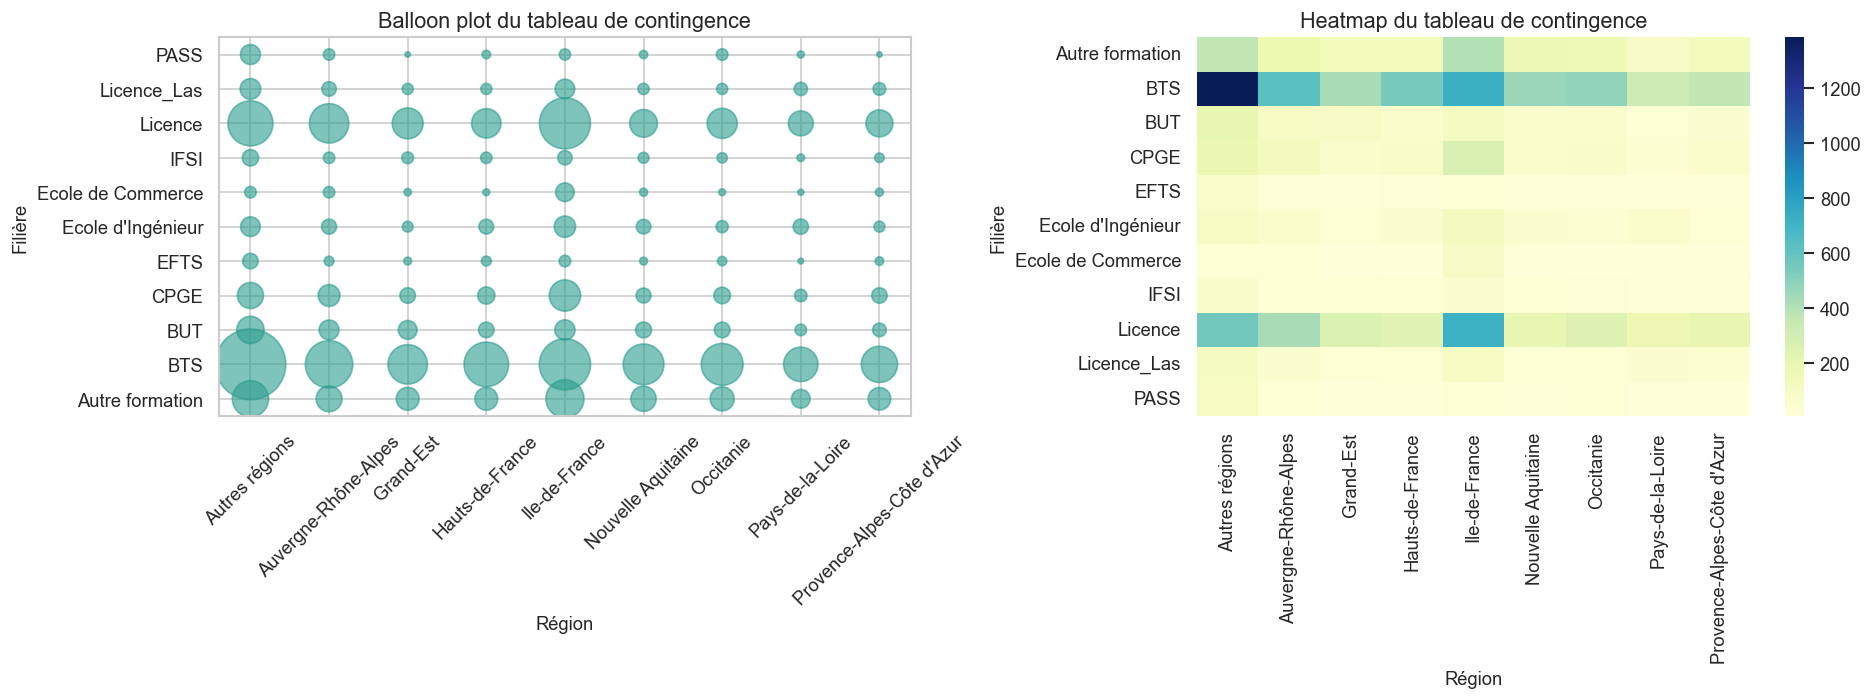

In [9]:
ct_long = contingency.reset_index().melt(id_vars="filiere_ca", var_name="region_ca", value_name="effectif")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(
    x=ct_long["region_ca"],
    y=ct_long["filiere_ca"],
    s=ct_long["effectif"] / ct_long["effectif"].max() * 1800,
    alpha=0.6,
    color="#2a9d8f",
)
axes[0].set_title("Balloon plot du tableau de contingence")
axes[0].set_xlabel("Région")
axes[0].set_ylabel("Filière")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(contingency, cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Heatmap du tableau de contingence")
axes[1].set_xlabel("Région")
axes[1].set_ylabel("Filière")

plt.tight_layout()
plt.show()

### Questions préalables, comme dans le TP

Avant la CA elle-même, on retrouve deux questions classiques du TP :

1. **Quelle cellule du tableau est la plus fréquente ?**
2. **La répartition observée diffère-t-elle significativement d'une situation d'indépendance ?**

Autrement dit : y a-t-il une structure entre type de filière et territoire, ou seulement des fluctuations aléatoires ?

In [ ]:
max_idx = contingency.stack().idxmax()
max_value = contingency.stack().max()
chi2, pvalue, dof, expected = chi2_contingency(contingency)

print(f"Cellule la plus fréquente : {max_idx} avec un effectif de {max_value}.")
print(f"Chi2 = {chi2:.2f}")
print(f"ddl = {dof}")
print(f"p-value = {pvalue:.4e}")

expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
display(expected_df.round(1).head())

Cellule la plus fréquente : ('BTS', 'Autres régions') avec un effectif de 1384.
Chi2 = 543.62
ddl = 80
p-value = 4.4393e-70


region_ca,Autres régions,Auvergne-Rhône-Alpes,Grand-Est,Hauts-de-France,Ile-de-France,Nouvelle Aquitaine,Occitanie,Pays-de-la-Loire,Provence-Alpes-Côte d'Azur
filiere_ca,,,,,,,,,
Autre formation,409.6,220.3,146.5,162.0,342.7,148.0,155.1,107.0,123.9
BTS,1207.5,649.5,431.8,477.6,1010.4,436.3,457.3,315.4,365.3
BUT,185.0,99.5,66.2,73.2,154.8,66.9,70.1,48.3,56.0
CPGE,222.5,119.7,79.6,88.0,186.2,80.4,84.3,58.1,67.3
EFTS,54.8,29.5,19.6,21.7,45.9,19.8,20.8,14.3,16.6


### Lecture intermédiaire

La cellule la plus fréquente correspond logiquement à une combinaison entre une modalité très présente de filière et une grande région. Ce n'est pas encore un résultat factoriel ; c'est seulement une **fréquence brute**.

En revanche, le test du khi-deux répond à la vraie question de départ : ici, la **p-value est extrêmement petite**, ce qui conduit à rejeter l'hypothèse d'indépendance. On a donc bien un tableau qui mérite une **analyse des correspondances** : certaines filières apparaissent plus ou moins liées à certains territoires que ce que l'indépendance prévoirait.

### Correspondence Analysis

Comme dans le TP d'origine, on lance maintenant la CA sur le tableau de contingence, puis on inspecte :
- les **valeurs propres** et pourcentages d'inertie ;
- les **coordonnées** des lignes et des colonnes ;
- la **carte factorielle**.

La question de cours reste la même : **combien de dimensions faut-il garder pour une lecture raisonnable ?**

In [25]:
ca = prince.CA(n_components=4, random_state=42).fit(contingency)
ca_eig = ca.eigenvalues_summary
row_coords = ca.row_coordinates(contingency)
col_coords = ca.column_coordinates(contingency)
row_cos2 = ca.row_cosine_similarities(contingency)
col_cos2 = ca.column_cosine_similarities(contingency)
row_masses = contingency.sum(axis=1) / contingency.values.sum()
col_masses = contingency.sum(axis=0) / contingency.values.sum()
row_contrib = row_coords.pow(2).mul(row_masses, axis=0).div(ca.eigenvalues_, axis=1) * 100
col_contrib = col_coords.pow(2).mul(col_masses, axis=0).div(ca.eigenvalues_, axis=1) * 100

print("Valeurs propres et inertie expliquée :")
display(ca_eig)

print()
print("Coordonnées des lignes (axes 1 et 2) :")
display(row_coords[[0, 1]].round(3))

print()
print("Coordonnées des colonnes (axes 1 et 2) :")
display(col_coords[[0, 1]].round(3))

Valeurs propres et inertie expliquée :


,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.025,65.80%,65.80%
1,0.005,13.02%,78.82%
2,0.004,10.37%,89.19%
3,0.002,5.14%,94.33%



Coordonnées des lignes (axes 1 et 2) :


,0,1
filiere_ca,,
Autre formation,-0.083,0.016
BTS,0.149,0.009
BUT,0.118,-0.119
CPGE,-0.220,-0.045
EFTS,0.132,-0.060
Ecole d'Ingénieur,-0.075,0.261
Ecole de Commerce,-0.493,-0.033
IFSI,0.053,-0.046
Licence,-0.151,-0.035



Coordonnées des colonnes (axes 1 et 2) :


,0,1
region_ca,,
Autres régions,0.169,-0.020
Auvergne-Rhône-Alpes,-0.049,-0.059
Grand-Est,0.021,-0.100
Hauts-de-France,0.110,0.034
Ile-de-France,-0.293,0.001
Nouvelle Aquitaine,0.058,0.058
Occitanie,0.085,-0.036
Pays-de-la-Loire,0.024,0.231
Provence-Alpes-Côte d'Azur,-0.027,0.016


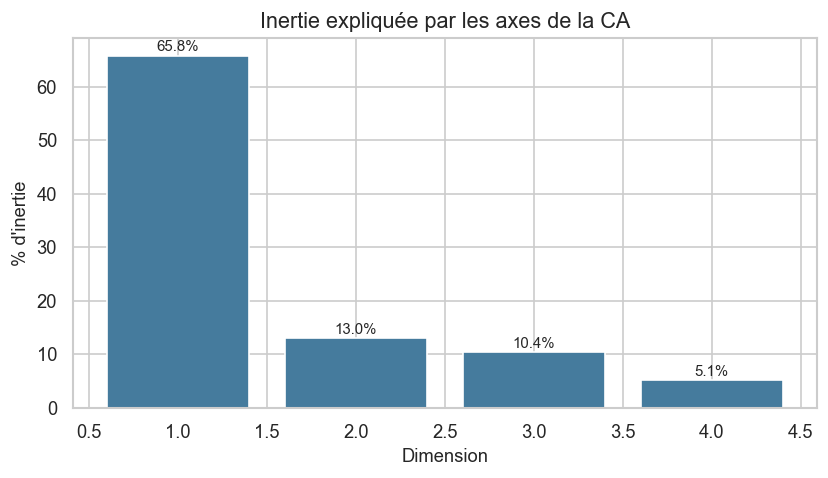

In [12]:
eig_pct = ca.percentage_of_variance_

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(eig_pct) + 1), eig_pct, color="#457b9d")
ax.set_xlabel("Dimension")
ax.set_ylabel("% d'inertie")
ax.set_title("Inertie expliquée par les axes de la CA")
for i, v in enumerate(eig_pct, start=1):
    ax.text(i, v + 0.8, f"{v:.1f}%", ha="center", fontsize=9)
plt.show()

### Interprétation de l'inertie

Comme dans le TP, on ne garde pas les dimensions au hasard. Ici, l'**axe 1 concentre l'essentiel de l'inertie**, et l'axe 2 apporte un complément utile mais plus secondaire.

Concrètement, le plan `(1,2)` suffit pour une première lecture pédagogique :
- l'axe 1 porte la structuration principale du tableau ;
- l'axe 2 affine l'interprétation ;
- les axes suivants existent, mais ils jouent un rôle plus faible dans la synthèse initiale.

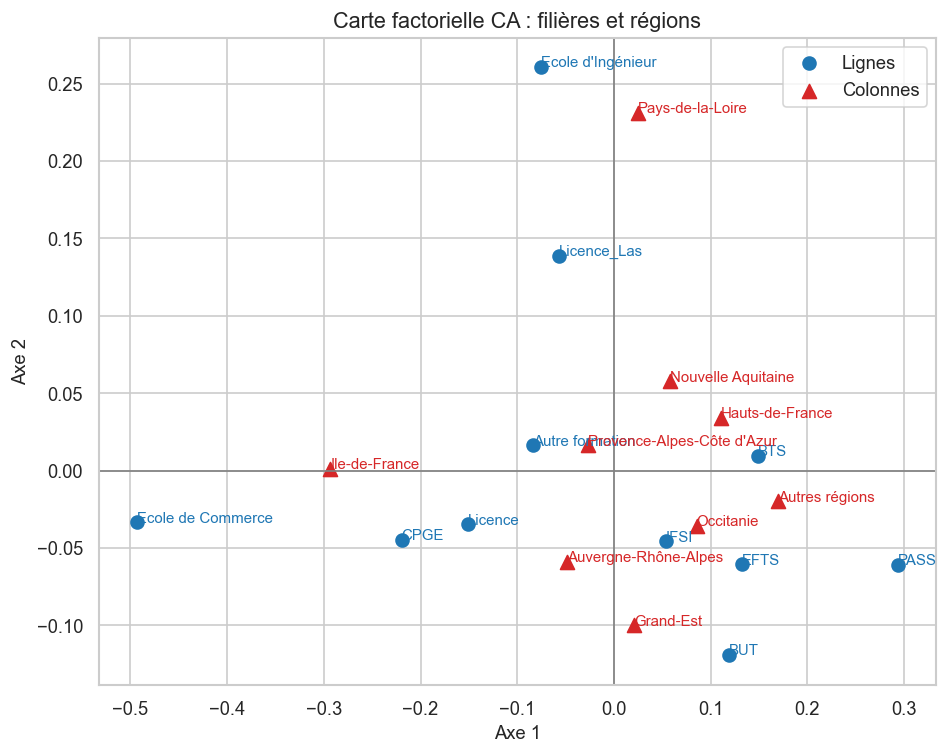

In [13]:
fig, ax = plt.subplots(figsize=(9, 7))
plot_ca_map(row_coords, col_coords, "Carte factorielle CA : filières et régions", ax=ax)
plt.show()

### Lecture de la carte factorielle

Cette carte joue le même rôle que le biplot du TP.

Quelques points de lecture importants :
- des modalités proches ont des **profils similaires** ;
- des modalités opposées de part et d'autre de l'origine ont des **profils contrastés** ;
- les modalités proches de l'origine sont moins structurantes.

Sur ces données, l'axe 1 oppose surtout un pôle où l'on retrouve davantage l'**Île-de-France** avec certaines filières comme les **Licences**, les **CPGE** ou les **Écoles de commerce**, à un autre pôle où l'on observe davantage des filières comme les **BTS** ou les **PASS**, davantage liées au reste du territoire.

L'axe 2 semble plus spécifique et plus localisé : il affine certains contrastes entre filières, mais avec une inertie plus faible. Il faut donc le commenter avec davantage de prudence.

### Qualité de représentation

Le TP insiste ensuite sur la question suivante : **quelles modalités sont bien représentées par les premiers axes ?**

On va donc regarder :
- quelles lignes sont bien représentées par l'axe 1 ;
- quelles lignes sont bien représentées par le plan `(1,2)` ;
- la même chose pour les colonnes.

C'est essentiel, car une modalité mal représentée ne doit pas être surinterprétée.

Ligne la mieux représentée par l'axe 1 :
filiere_ca
BTS    0.983756
Name: 0, dtype: float64

Lignes les mieux représentées sur le plan (1,2) :


,cos2_plan
filiere_ca,
BTS,0.987734
Ecole de Commerce,0.936971
Ecole d'Ingénieur,0.923238
Licence,0.906810
CPGE,0.877272
BUT,0.681344
EFTS,0.532678
Licence_Las,0.492042
Autre formation,0.408657



Colonnes les mieux représentées sur le plan (1,2) :


,cos2_plan
region_ca,
Ile-de-France,0.983733
Pays-de-la-Loire,0.869703
Autres régions,0.857378
Occitanie,0.598891
Hauts-de-France,0.566547
Auvergne-Rhône-Alpes,0.469993
Nouvelle Aquitaine,0.336095
Grand-Est,0.295720
Provence-Alpes-Côte d'Azur,0.065032


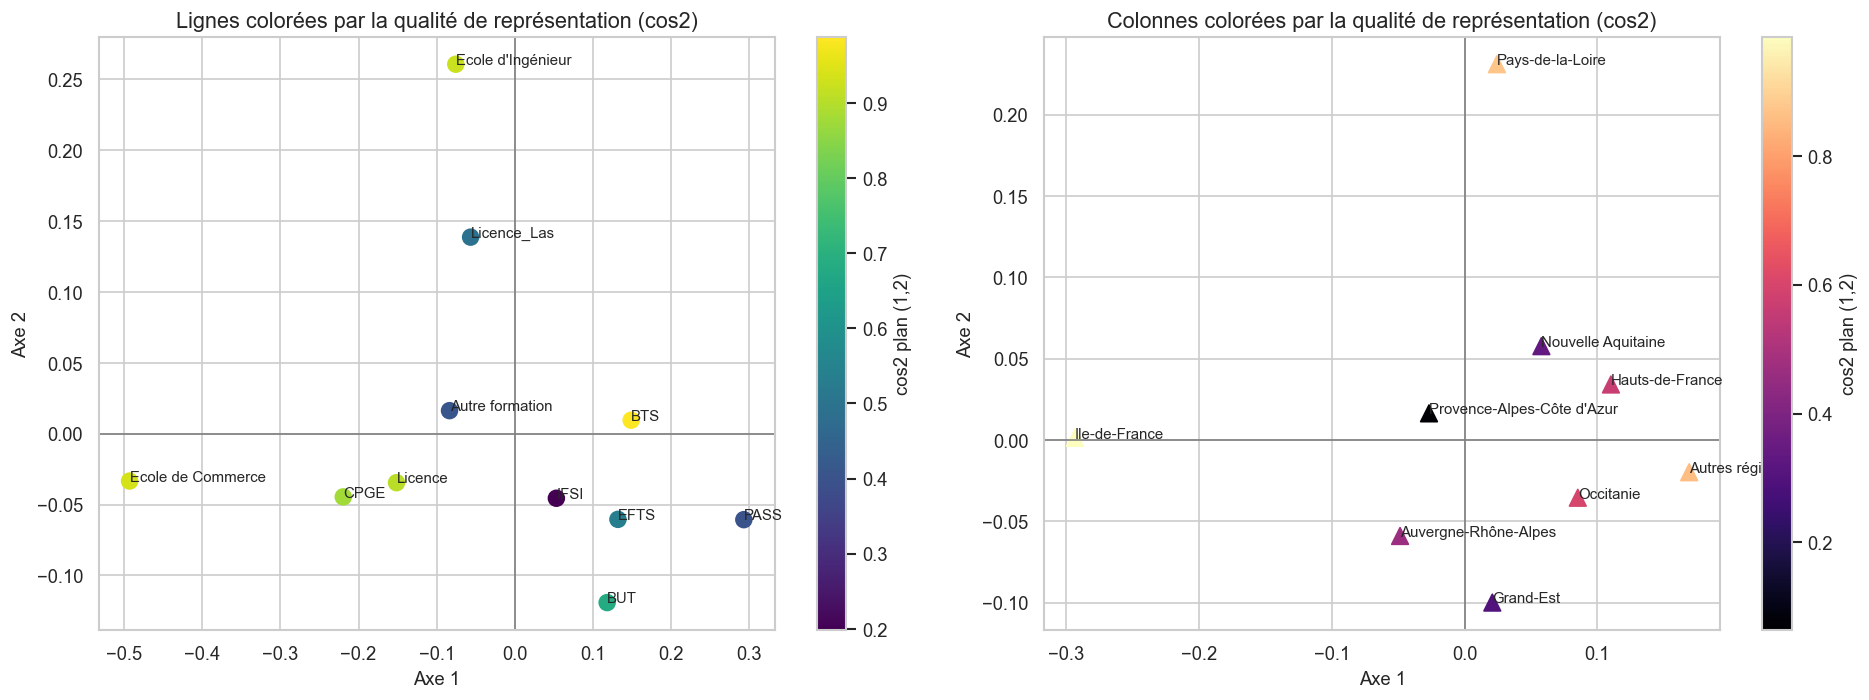

In [14]:
row_cos2_plane = row_cos2[0] + row_cos2[1]
col_cos2_plane = col_cos2[0] + col_cos2[1]

print("Ligne la mieux représentée par l'axe 1 :")
print(row_cos2[0].sort_values(ascending=False).head(1))

print()
print("Lignes les mieux représentées sur le plan (1,2) :")
display(row_cos2_plane.sort_values(ascending=False).head(10).to_frame("cos2_plan"))

print()
print("Colonnes les mieux représentées sur le plan (1,2) :")
display(col_cos2_plane.sort_values(ascending=False).head(10).to_frame("cos2_plan"))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].axhline(0, color="grey", lw=1)
axes[0].axvline(0, color="grey", lw=1)
sc1 = axes[0].scatter(row_coords[0], row_coords[1], c=row_cos2_plane, cmap="viridis", s=90)
for idx, (x, y) in row_coords[[0, 1]].iterrows():
    axes[0].text(x, y, idx, fontsize=9)
axes[0].set_title("Lignes colorées par la qualité de représentation (cos2)")
axes[0].set_xlabel("Axe 1")
axes[0].set_ylabel("Axe 2")
plt.colorbar(sc1, ax=axes[0], label="cos2 plan (1,2)")

axes[1].axhline(0, color="grey", lw=1)
axes[1].axvline(0, color="grey", lw=1)
sc2 = axes[1].scatter(col_coords[0], col_coords[1], c=col_cos2_plane, cmap="magma", s=100, marker="^")
for idx, (x, y) in col_coords[[0, 1]].iterrows():
    axes[1].text(x, y, idx, fontsize=9)
axes[1].set_title("Colonnes colorées par la qualité de représentation (cos2)")
axes[1].set_xlabel("Axe 1")
axes[1].set_ylabel("Axe 2")
plt.colorbar(sc2, ax=axes[1], label="cos2 plan (1,2)")

plt.tight_layout()
plt.show()

### Lecture de la qualité de représentation

Comme dans le TP, on retient surtout les modalités dont le `cos2` est élevé.

Ici, plusieurs filières comme **BTS**, **Licence**, **CPGE** ou encore **École de commerce** sont bien projetées sur le plan principal, ce qui autorise une interprétation assez robuste de leur position.

Côté colonnes, **Île-de-France** et **Pays-de-la-Loire** sont particulièrement lisibles sur le plan `(1,2)`. À l'inverse, des régions plus proches du centre ou plus équilibrées entre filières doivent être interprétées avec plus de prudence.

### Contribution aux dimensions

Le TP poursuit ensuite avec la question des **contributions** : quelles modalités fabriquent réellement les axes ?

C'est une étape clé, car une modalité peut être loin de l'origine sans forcément contribuer beaucoup. Ici, on regarde donc :
- les contributions des lignes aux axes 1 et 2 ;
- les contributions des colonnes ;
- une synthèse graphique pour repérer les modalités les plus structurantes.

Ligne qui contribue le plus à l'axe 2 :
filiere_ca
Ecole d'Ingénieur    56.146812
Name: 1, dtype: float64


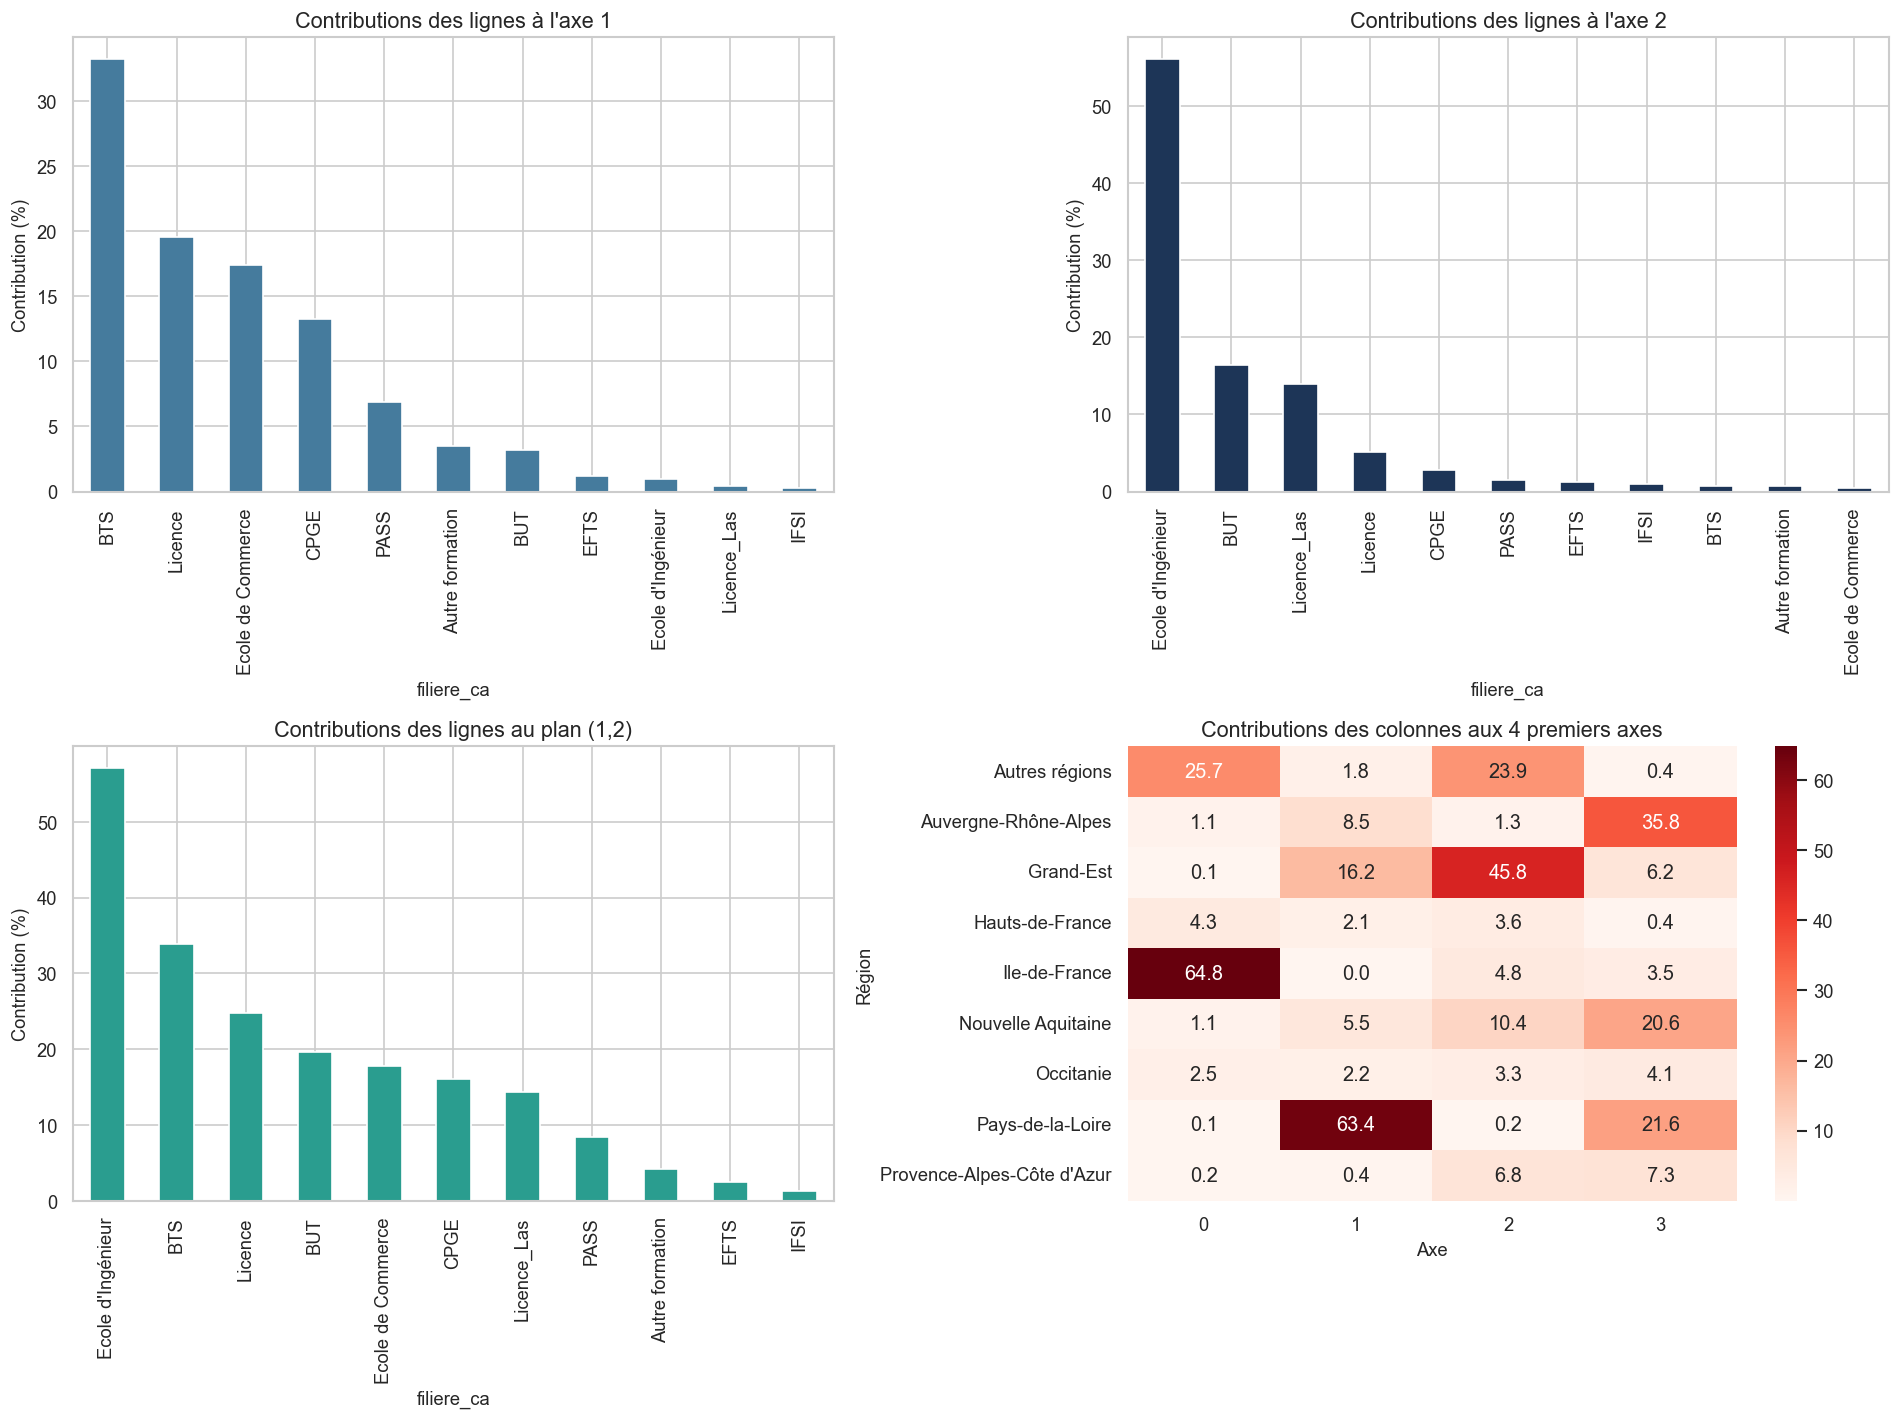

In [15]:
print("Ligne qui contribue le plus à l'axe 2 :")
print(row_contrib[1].sort_values(ascending=False).head(1))

row_contrib_plane = row_contrib[0] + row_contrib[1]
col_contrib_plane = col_contrib[0] + col_contrib[1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

row_contrib[0].sort_values(ascending=False).plot(kind="bar", ax=axes[0, 0], color="#457b9d")
axes[0, 0].set_title("Contributions des lignes à l'axe 1")
axes[0, 0].set_ylabel("Contribution (%)")

row_contrib[1].sort_values(ascending=False).plot(kind="bar", ax=axes[0, 1], color="#1d3557")
axes[0, 1].set_title("Contributions des lignes à l'axe 2")
axes[0, 1].set_ylabel("Contribution (%)")

row_contrib_plane.sort_values(ascending=False).plot(kind="bar", ax=axes[1, 0], color="#2a9d8f")
axes[1, 0].set_title("Contributions des lignes au plan (1,2)")
axes[1, 0].set_ylabel("Contribution (%)")

sns.heatmap(col_contrib.iloc[:, :4], annot=True, fmt=".1f", cmap="Reds", ax=axes[1, 1])
axes[1, 1].set_title("Contributions des colonnes aux 4 premiers axes")
axes[1, 1].set_xlabel("Axe")
axes[1, 1].set_ylabel("Région")

plt.tight_layout()
plt.show()

### Interprétation synthétique de la CA

On retrouve bien ici le raisonnement du TP :

- **Axe 1** : il est surtout porté par des filières comme **BTS** et **Licence**, ainsi que par l'opposition entre **Île-de-France** et le reste du territoire. C'est donc l'axe majeur de différenciation entre profils territoriaux de formation.
- **Axe 2** : il est plus secondaire et davantage influencé par des modalités spécifiques, par exemple certaines filières plus spécialisées ou certaines régions particulières. On le lit donc comme un axe d'ajustement, pas comme la structure centrale.
- Les conclusions les plus solides sont celles qui concernent des modalités à la fois **contributives** et **bien représentées**.

Comme toujours en CA, on parle ici d'**associations de profils** et non de causalité.

## MCA / ACM - Analyse des correspondances multiples

On passe maintenant à l'analogue de la seconde partie du TP.

Dans le notebook source, l'ACM sert à étudier un **ensemble de variables qualitatives** décrivant les individus. Ici, les "individus" sont les **formations Parcoursup**, et on cherche à voir si plusieurs dimensions qualitatives dessinent des profils cohérents.

### Choix des variables actives

On retient des variables qualitatives ou discrétisées qui ont un sens métier :
- sélectivité ;
- statut de l'établissement ;
- type de filière ;
- niveau de pression de candidature ;
- niveau d'accès ;
- niveau académique des admis ;
- poids des boursiers parmi les admis ;
- féminisation ;
- profil dominant des admis ;
- taille de la formation.

Comme dans le TP, certaines variables numériques sont donc **transformées en classes** pour devenir exploitables dans une ACM.

In [16]:
mca_base = analysis.loc[(analysis["admis_total"] > 0) & (analysis["admis_neobac"] > 0)].copy()
regions_top6 = mca_base["region"].value_counts(dropna=True).head(6).index
mca_base["region_mca"] = mca_base["region"].where(mca_base["region"].isin(regions_top6), "Autres régions").fillna("Région non renseignée")

mca_df = pd.DataFrame({
    "Sélectivité": mca_base["selectivite"].fillna("Non renseigné"),
    "Statut": mca_base["statut"].fillna("Non renseigné"),
    "Filière": mca_base["filiere_agregee"].fillna("Non renseigné"),
    "Pression": qcut_label(mca_base["pression"], ["Pression faible", "Pression modérée", "Pression forte", "Pression très forte"]),
    "Accès": qcut_label(mca_base["taux_acces"], ["Accès difficile", "Accès intermédiaire bas", "Accès intermédiaire haut", "Accès ouvert"]),
    "Mentions": qcut_label(mca_base["score_mentions"], ["Mentions faibles", "Mentions intermédiaires", "Mentions élevées", "Mentions très élevées"]),
    "Boursiers": qcut_label(mca_base["pct_boursiers"], ["Peu de boursiers", "Boursiers assez peu présents", "Boursiers présents", "Beaucoup de boursiers"]),
    "Féminisation": pd.cut(
        mca_base["pct_filles"],
        bins=[-np.inf, 40, 60, np.inf],
        labels=["Majoritairement masculine", "Mixte", "Majoritairement féminine"],
    ).astype("object").fillna("Non renseigné"),
    "Profil admis": pd.Series(mca_base["profil_admis"], index=mca_base.index).fillna("Non renseigné"),
    "Taille": qcut_label(mca_base["capacite"], ["Petite capacité", "Capacité moyenne basse", "Capacité moyenne haute", "Grande capacité"]),
    "Région": mca_base["region_mca"],
}).astype(str)

active_vars = [
    "Sélectivité", "Statut", "Filière", "Pression", "Accès",
    "Mentions", "Boursiers", "Féminisation", "Profil admis", "Taille"
]
quali_sup_vars = ["Région"]

print(f"Jeu ACM : {mca_df.shape[0]} individus x {mca_df.shape[1]} variables")
display(mca_df.head())

display(pd.DataFrame({
    "role": ["active"] * len(active_vars) + ["qualitative supplémentaire"] * len(quali_sup_vars),
    "variable": active_vars + quali_sup_vars,
}))

Jeu ACM : 13954 individus x 11 variables


,Sélectivité,Statut,Filière,Pression,Accès,Mentions,Boursiers,Féminisation,Profil admis,Taille,Région
0,formation sélective,Public,Autre formation,Pression forte,Accès difficile,Mentions très élevées,Boursiers présents,Majoritairement féminine,Dominante générale,Capacité moyenne haute,Auvergne-Rhône-Alpes
1,formation non sélective,Public,Licence,Pression modérée,Accès ouvert,Mentions faibles,Boursiers assez peu présents,Majoritairement féminine,Profil mixte,Capacité moyenne haute,Ile-de-France
2,formation sélective,Public,IFSI,Pression très forte,Accès intermédiaire bas,Mentions élevées,Boursiers assez peu présents,Majoritairement féminine,Dominante technologique,Grande capacité,Auvergne-Rhône-Alpes
3,formation non sélective,Public,PASS,Pression très forte,Accès intermédiaire bas,Mentions très élevées,Boursiers assez peu présents,Mixte,Dominante générale,Grande capacité,Auvergne-Rhône-Alpes
4,formation non sélective,Public,PASS,Pression très forte,Accès difficile,Mentions très élevées,Boursiers assez peu présents,Majoritairement féminine,Dominante générale,Grande capacité,Auvergne-Rhône-Alpes


,role,variable
0,active,Sélectivité
1,active,Statut
2,active,Filière
3,active,Pression
4,active,Accès
5,active,Mentions
6,active,Boursiers
7,active,Féminisation
8,active,Profil admis
9,active,Taille


### Lecture méthodologique

Ce passage est l'analogue direct de la préparation du tableau `hobbies` dans le TP.

On a volontairement :
- **filtré** les formations sans admis observables ou sans néo-bacheliers admis, afin d'éviter que des modalités `Non renseigné` dominent artificiellement l'ACM ;
- **regroupé** le statut privé hors contrat et le privé d'enseignement supérieur dans `Autre privé` ;
- **discrétisé** plusieurs variables continues en classes ordinales simples.

L'objectif est de garder une ACM lisible, interprétable et proche du rythme du cours.


### Sélectivité


,effectif
Sélectivité,
formation sélective,10788
formation non sélective,3166



### Statut


,effectif
Statut,
Public,10999
Privé sous contrat d'association,1873
Autre privé,1082



### Filière


...

,effectif
Féminisation,
Majoritairement féminine,5992
Majoritairement masculine,5122
Mixte,2840



### Profil admis


,effectif
Profil admis,
Dominante générale,7191
Dominante professionnelle,3099
Dominante technologique,2576
Profil mixte,1088



### Taille


,effectif
Taille,
Capacité moyenne basse,3540
Petite capacité,3504
Grande capacité,3478
Capacité moyenne haute,3432


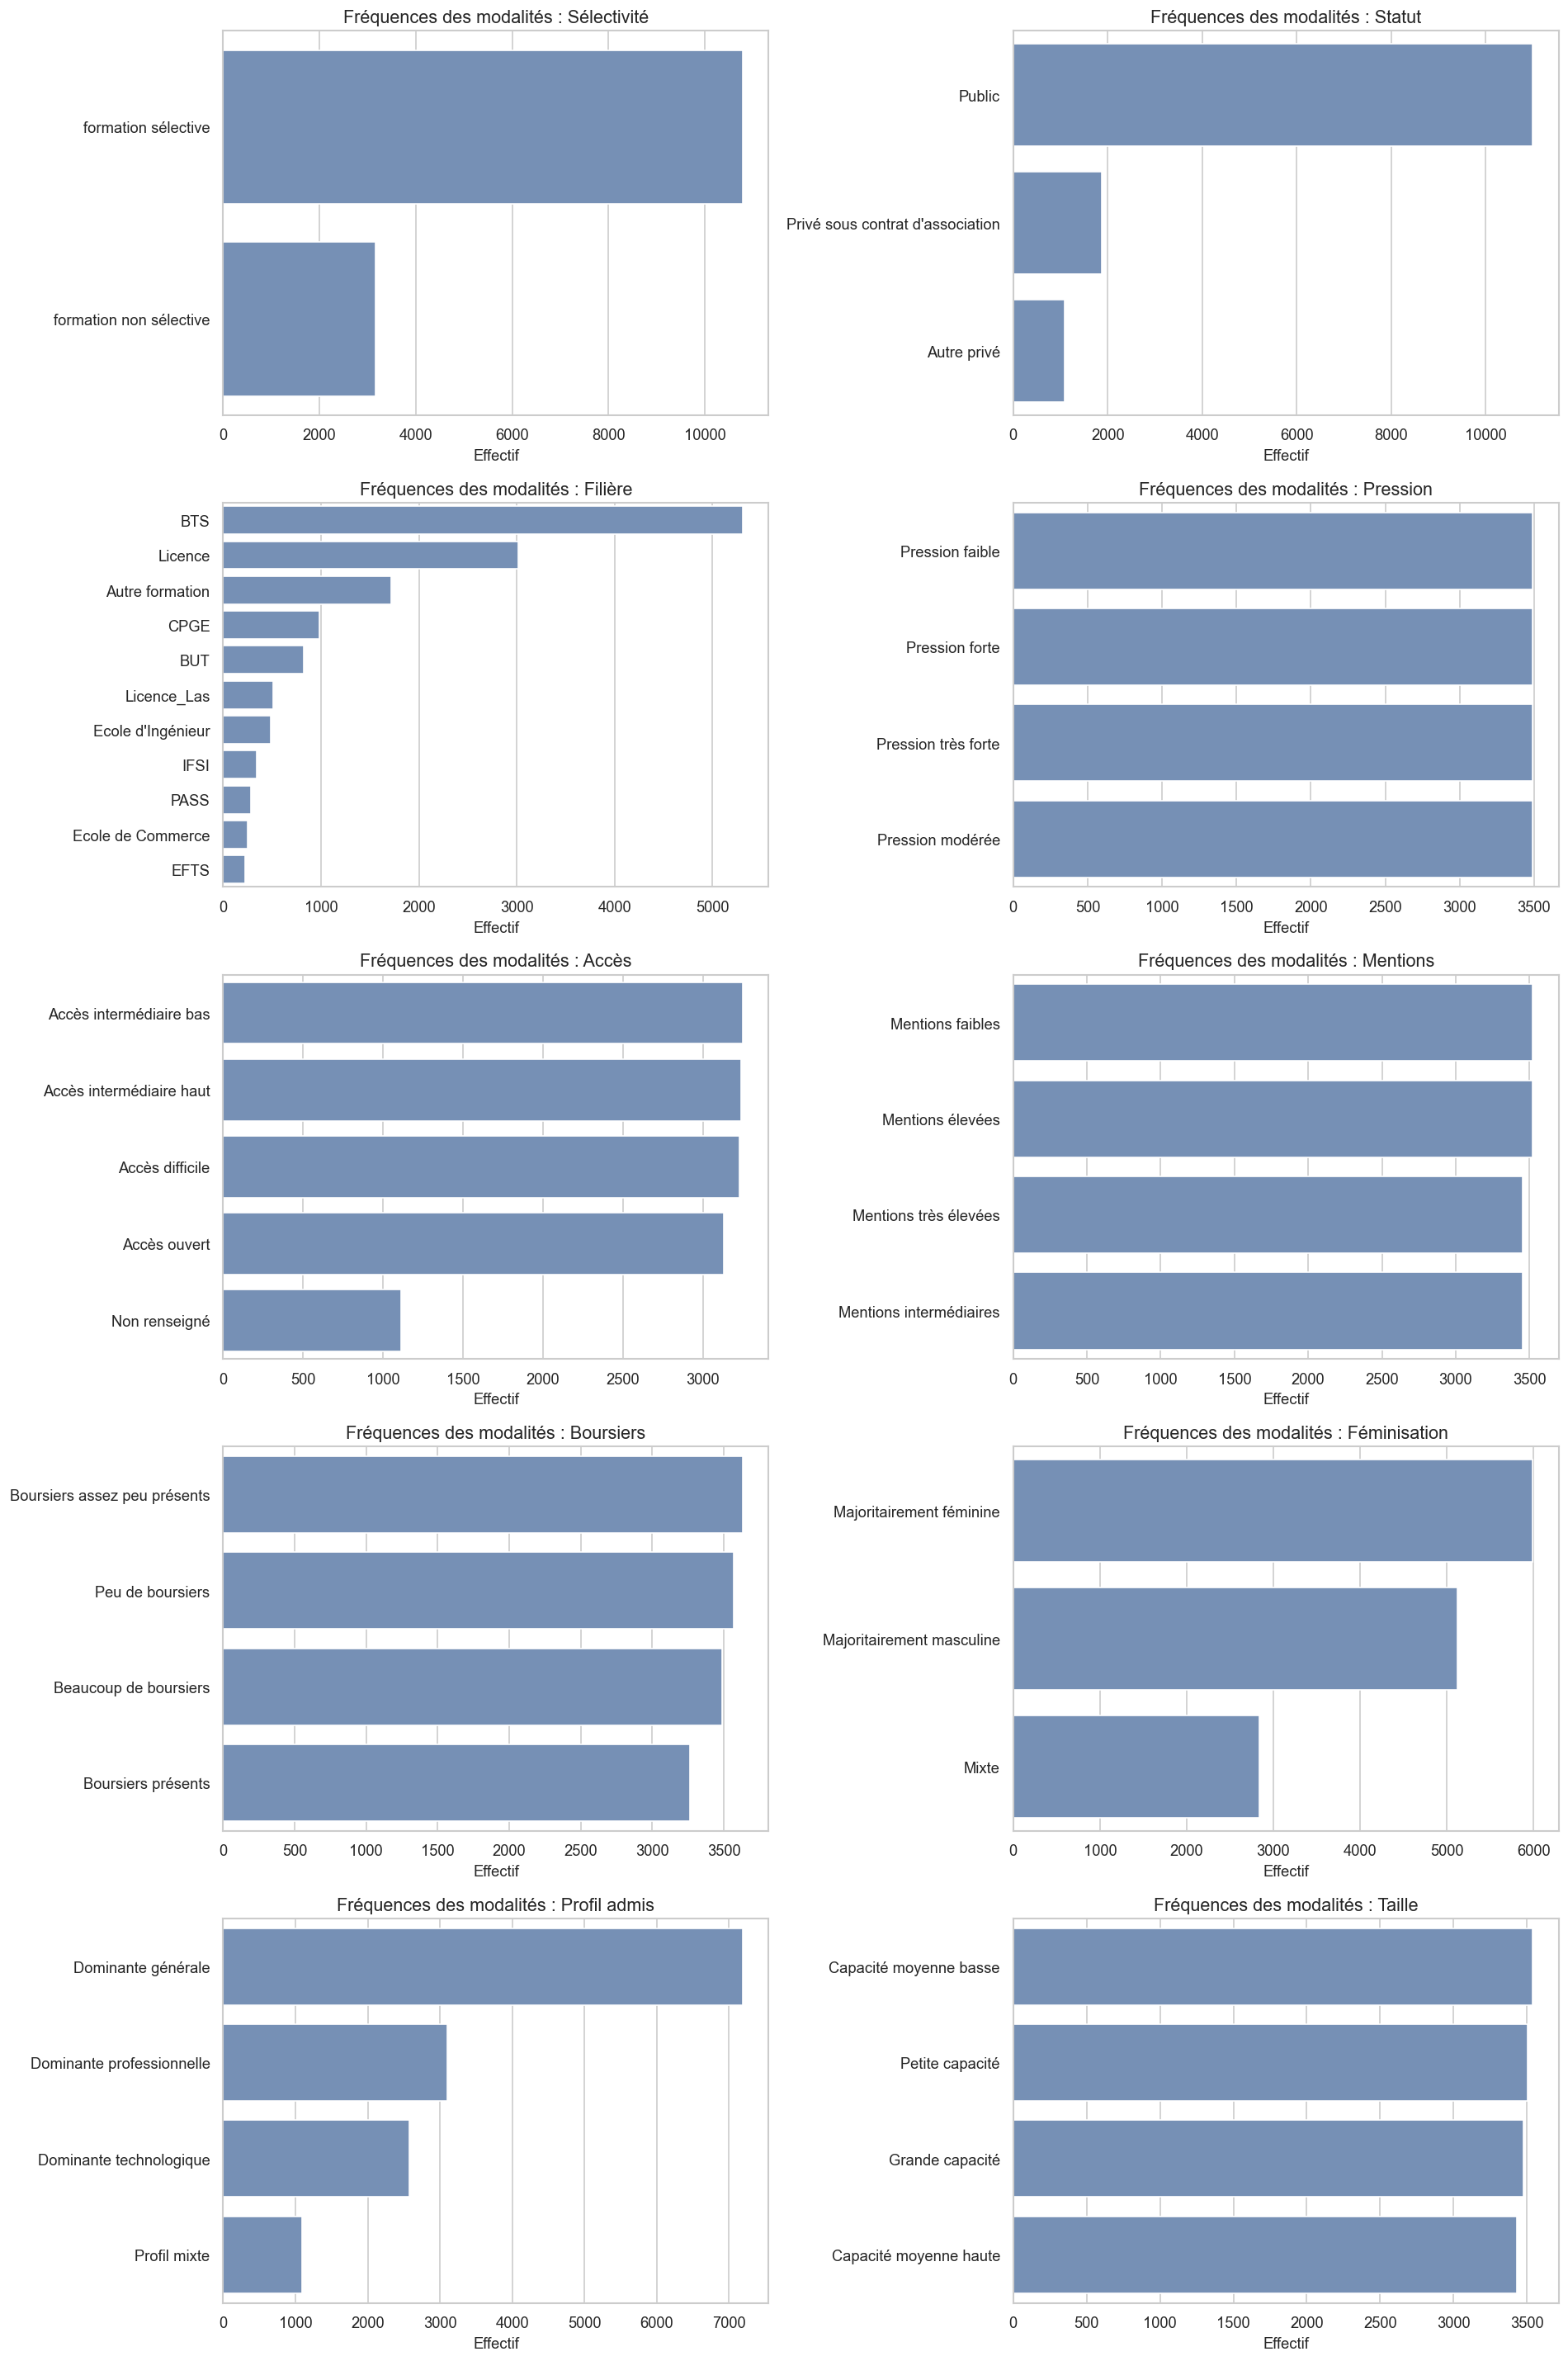

In [17]:
freq_tables = {
    col: mca_df[col].value_counts().rename("effectif")
    for col in active_vars
}

for col in active_vars:
    print()
    print(f"### {col}")
    display(freq_tables[col].to_frame())

fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.ravel()
for ax, col in zip(axes, active_vars):
    counts = mca_df[col].value_counts()
    sns.barplot(x=counts.values, y=counts.index, ax=ax, color="#6c8ebf")
    ax.set_title(f"Fréquences des modalités : {col}")
    ax.set_xlabel("Effectif")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

> **Remarque, comme dans le TP :** les graphiques de fréquences servent aussi à repérer les modalités trop rares. Ici, certaines filières spécialisées restent peu fréquentes, mais elles ne sont pas assez marginales pour être retirées d'emblée. On les garde donc, tout en sachant qu'elles seront parfois moins bien représentées sur le plan principal.

### Multiple Correspondence Analysis

On estime maintenant l'ACM sur les **variables actives**, puis on suit la même logique que dans le TP :
- inertie par axe ;
- carte des modalités ;
- qualité de représentation ;
- contributions ;
- lecture des axes.

La région sera utilisée plus loin comme **variable de contexte**, dans l'esprit des éléments supplémentaires de la fin du TP source.

In [18]:
mca = prince.MCA(n_components=5, random_state=42).fit(mca_df[active_vars])
mca_eig = mca.eigenvalues_summary
row_coords_mca = mca.row_coordinates(mca_df[active_vars])
mod_coords = mca.column_coordinates(mca_df[active_vars])
mod_cos2 = mca.column_cosine_similarities(mca_df[active_vars])
ind_cos2 = mca.row_cosine_similarities(mca_df[active_vars])

X = pd.get_dummies(mca_df[active_vars], prefix_sep="__")
mod_masses = X.sum(axis=0) / X.values.sum()
mod_contrib = mod_coords.pow(2).mul(mod_masses, axis=0).div(mca.eigenvalues_, axis=1) * 100

print("Valeurs propres et inertie expliquée :")
display(mca_eig)

Valeurs propres et inertie expliquée :


,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.315,9.26%,9.26%
1,0.235,6.91%,16.18%
2,0.204,5.99%,22.16%
3,0.165,4.87%,27.03%
4,0.157,4.61%,31.65%


### Lecture de l'inertie de l'ACM

Comme dans le TP d'origine, les pourcentages d'inertie par axe sont **modestes**. C'est normal en ACM : quand on a beaucoup de modalités, l'information se répartit sur plusieurs dimensions.

Ici encore, le plan `(1,2)` ne résume pas tout, mais il donne une **première lecture solide**. On s'en sert donc comme plan principal, tout en gardant à l'esprit que d'autres axes existent et peuvent porter des nuances supplémentaires.

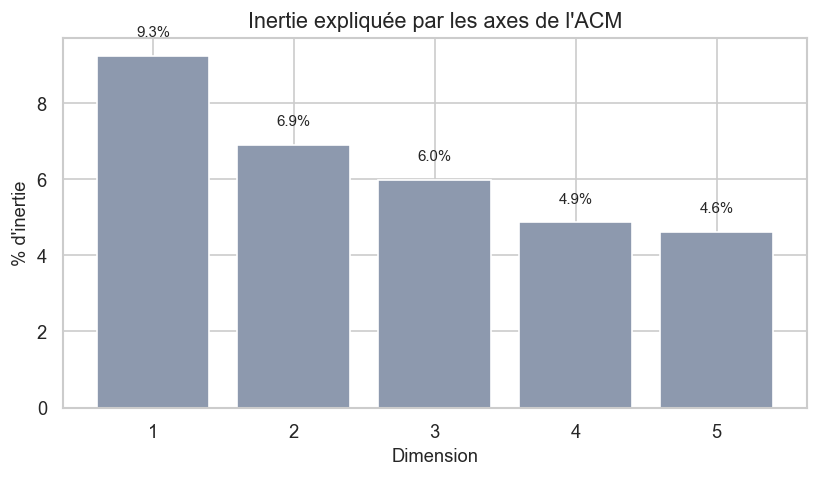

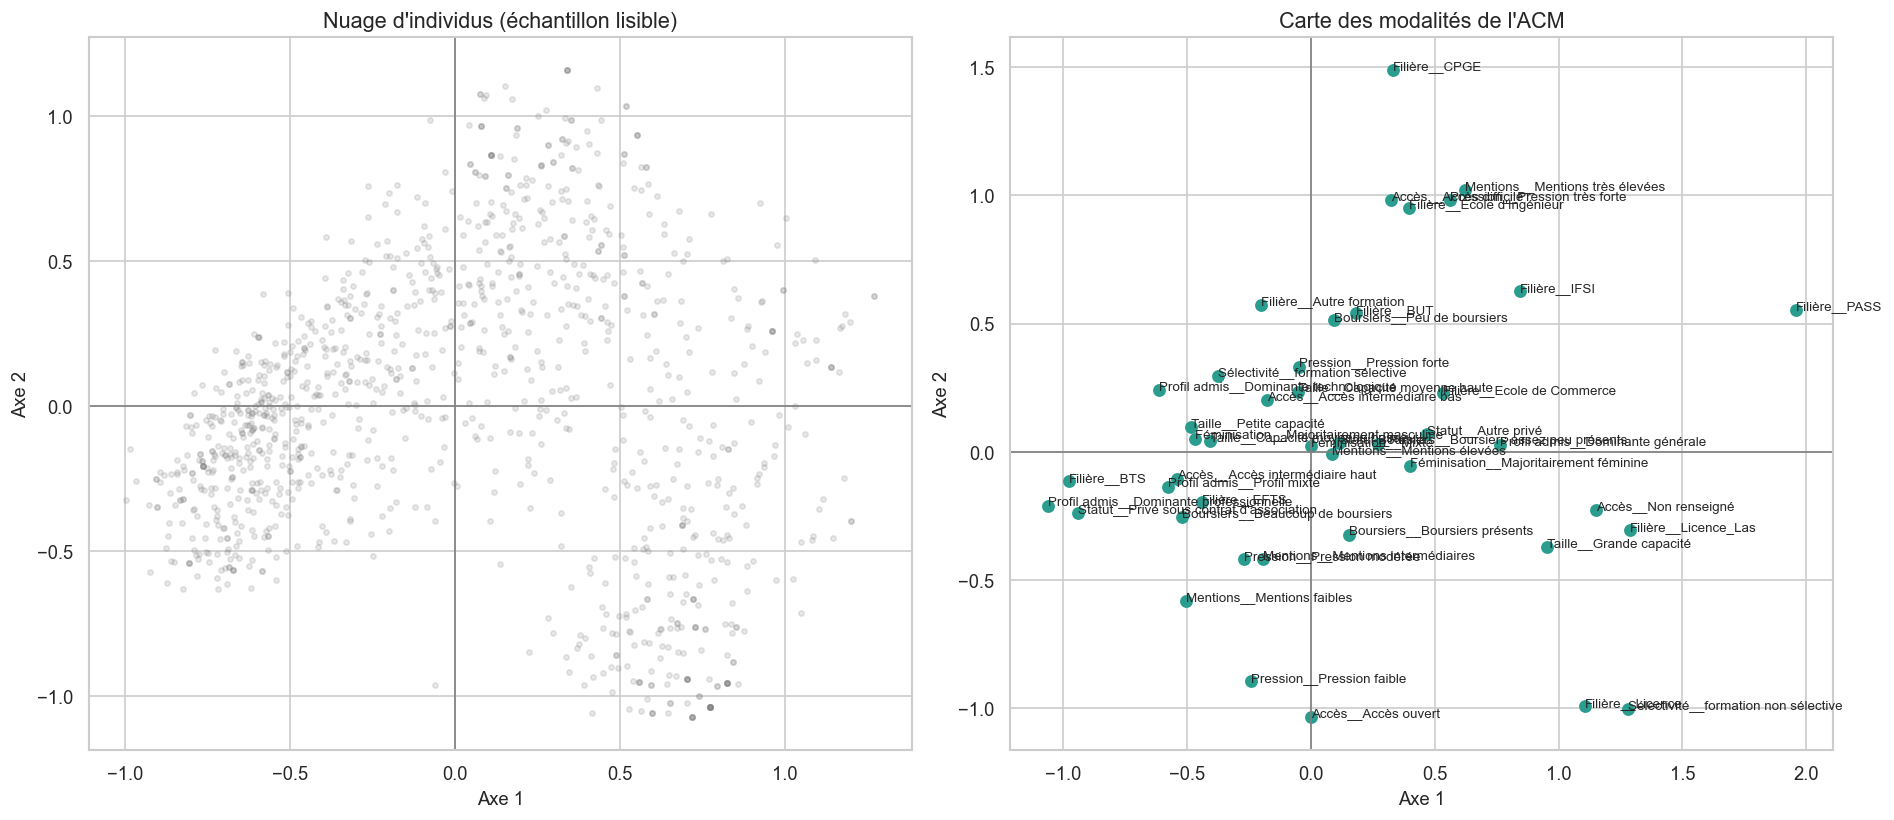

In [19]:
eig_pct_mca = mca.percentage_of_variance_

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(eig_pct_mca) + 1), eig_pct_mca, color="#8d99ae")
ax.set_xlabel("Dimension")
ax.set_ylabel("% d'inertie")
ax.set_title("Inertie expliquée par les axes de l'ACM")
for i, v in enumerate(eig_pct_mca, start=1):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)
plt.show()

sample_idx = row_coords_mca.sample(n=min(1200, len(row_coords_mca)), random_state=42).index
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].scatter(row_coords_mca.loc[sample_idx, 0], row_coords_mca.loc[sample_idx, 1], s=10, alpha=0.18, color="grey")
axes[0].axhline(0, color="grey", lw=1)
axes[0].axvline(0, color="grey", lw=1)
axes[0].set_title("Nuage d'individus (échantillon lisible)")
axes[0].set_xlabel("Axe 1")
axes[0].set_ylabel("Axe 2")

plot_mca_modalities(mod_coords, "Carte des modalités de l'ACM", ax=axes[1])
plt.tight_layout()
plt.show()

### Que lit-on sur le plan principal ?

La carte des modalités est l'analogue du biplot de l'ACM du TP.

Sur ces données, le plan principal fait apparaître une opposition assez nette entre :
- un pôle où l'on retrouve davantage les **formations non sélectives**, les **Licences**, les **grandes capacités** et les profils à **dominante générale** ;
- un autre pôle où l'on observe plus souvent des **BTS**, des profils à **dominante professionnelle** ou technologique, et des formations plus petites ou plus spécialisées.

L'axe 2 affine ensuite cette lecture en opposant plutôt des formations **très demandées, difficiles d'accès et avec de très bonnes mentions** à des formations **plus ouvertes**, avec une pression plus faible.

### Corrélation des variables avec les axes

Dans le TP, une étape importante consiste à se demander : **quelles variables expliquent le plus chaque axe ?**

En Python, on peut approcher cette idée avec un **eta²** entre chaque variable qualitative et les coordonnées des individus sur les axes 1 et 2. Cela permet de voir quelles variables structurent vraiment le plan principal.

,Axe 1,Axe 2
Filière,0.812798,0.484034
Profil admis,0.647815,0.022313
Sélectivité,0.482253,0.296311
Taille,0.327926,0.050637
Accès,0.204698,0.480032
Mentions,0.171390,0.386447
Féminisation,0.149311,0.002362
Statut,0.146230,0.008967
Pression,0.111625,0.511541
Boursiers,0.094732,0.108202


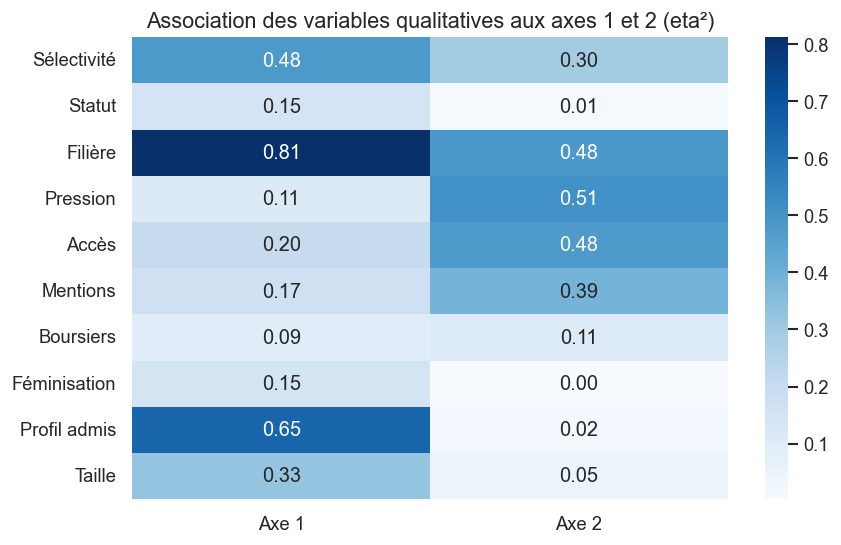

In [20]:
eta2 = pd.DataFrame(
    {
        f"Axe {dim+1}": [eta_squared(mca_df[var], row_coords_mca[dim]) for var in active_vars]
        for dim in range(2)
    },
    index=active_vars,
)

display(eta2.sort_values("Axe 1", ascending=False))

plt.figure(figsize=(8, 5))
sns.heatmap(eta2, annot=True, fmt=".2f", cmap="Blues")
plt.title("Association des variables qualitatives aux axes 1 et 2 (eta²)")
plt.show()

### Lecture de l'association variable-axe

On retrouve ici un résultat très utile pour l'interprétation :

- **Axe 1** est surtout lié à la **filière**, au **profil des admis** et à la **sélectivité** ;
- **Axe 2** est surtout lié à la **pression de candidature**, au **niveau d'accès**, aux **mentions** et, dans une moindre mesure, au type de filière.

Autrement dit :
- l'axe 1 décrit surtout des **profils de formations** ;
- l'axe 2 décrit davantage un **gradient d'ouverture / tension / niveau académique**.

### Qualité de représentation

Comme dans le TP, on vérifie maintenant quelles modalités et quels individus sont bien projetés sur le plan `(1,2)`.

C'est indispensable pour éviter les interprétations trop rapides :
- une modalité avec un `cos2` élevé est bien résumée par les deux premiers axes ;
- une modalité avec un `cos2` faible demande plus de prudence ;
- pour les individus, il est normal qu'ils ne soient pas tous aussi bien représentés.

Modalités les mieux représentées sur le plan (1,2) :


,cos2_plan
Sélectivité__formation sélective,0.778565
Sélectivité__formation non sélective,0.778565
Profil admis__Dominante générale,0.622870
Filière__Licence,0.607067
Filière__BTS,0.595631
Mentions__Mentions très élevées,0.469632
Pression__Pression très forte,0.424908
Taille__Grande capacité,0.347515
Profil admis__Dominante professionnelle,0.335192
Accès__Accès difficile,0.322626


Modalités les moins bien représentées sur le plan (1,2) :


,cos2_plan
Féminisation__Mixte,0.000126
Mentions__Mentions élevées,0.002520
Filière__EFTS,0.003814
Filière__Ecole de Commerce,0.006158
Statut__Autre privé,0.018718
Taille__Capacité moyenne haute,0.018912
Filière__BUT,0.020399
Accès__Accès intermédiaire bas,0.021987
Boursiers__Boursiers assez peu présents,0.026019
Filière__IFSI,0.027832


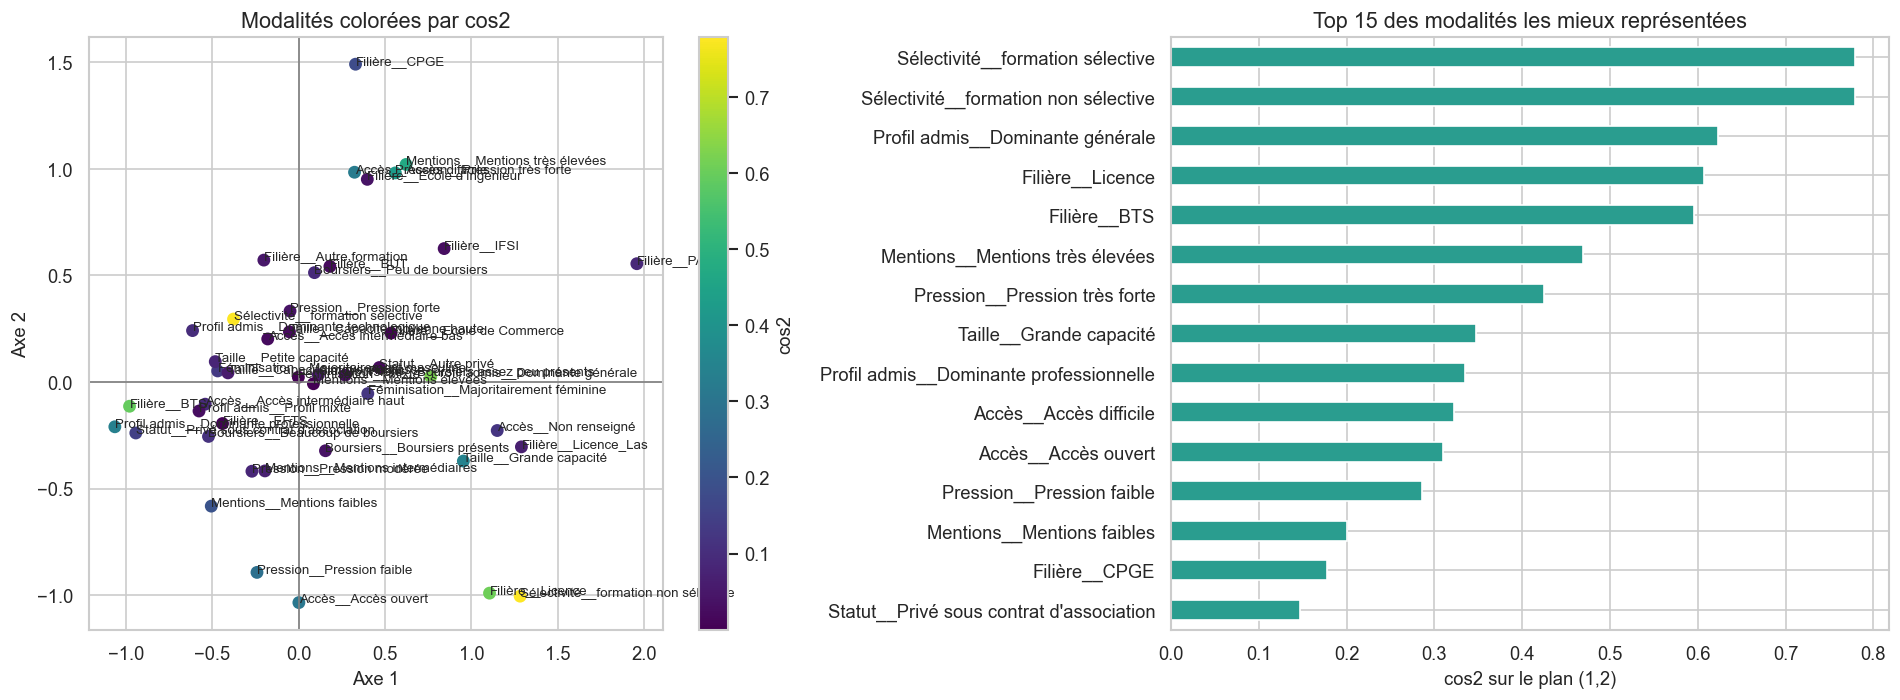

Part des individus ayant un cos2 plan (1,2) >= 0.2 : 0.376
Part des individus ayant un cos2 plan (1,2) >= 0.5 : 0.036


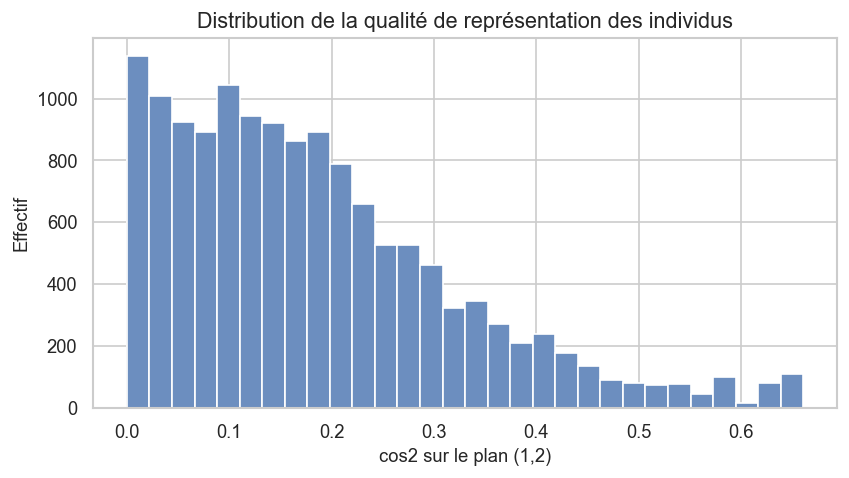

In [21]:
mod_cos2_plane = mod_cos2[0] + mod_cos2[1]
ind_cos2_plane = ind_cos2[0] + ind_cos2[1]

print("Modalités les mieux représentées sur le plan (1,2) :")
display(mod_cos2_plane.sort_values(ascending=False).head(12).to_frame("cos2_plan"))

print("Modalités les moins bien représentées sur le plan (1,2) :")
display(mod_cos2_plane.sort_values().head(12).to_frame("cos2_plan"))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_mca_modalities(mod_coords, "Modalités colorées par cos2", color=mod_cos2_plane.rename("cos2"), ax=axes[0])

mod_cos2_plane.sort_values(ascending=False).head(15).sort_values().plot(kind="barh", ax=axes[1], color="#2a9d8f")
axes[1].set_title("Top 15 des modalités les mieux représentées")
axes[1].set_xlabel("cos2 sur le plan (1,2)")

plt.tight_layout()
plt.show()

print(f"Part des individus ayant un cos2 plan (1,2) >= 0.2 : {(ind_cos2_plane >= 0.2).mean():.3f}")
print(f"Part des individus ayant un cos2 plan (1,2) >= 0.5 : {(ind_cos2_plane >= 0.5).mean():.3f}")

plt.figure(figsize=(8, 4))
plt.hist(ind_cos2_plane, bins=30, color="#6c8ebf", edgecolor="white")
plt.title("Distribution de la qualité de représentation des individus")
plt.xlabel("cos2 sur le plan (1,2)")
plt.ylabel("Effectif")
plt.show()

### Lecture de la qualité de représentation en ACM

On retrouve exactement la mise en garde du TP : **toutes les modalités et tous les individus ne sont pas également bien représentés**.

Ici, les modalités liées à la **sélectivité**, aux grandes **filières** (comme BTS ou Licence), aux **mentions très élevées** ou à la **pression très forte** sont globalement mieux projetées sur le plan principal. En revanche, certaines modalités intermédiaires ou plus rares restent plus floues.

Pour les individus, seule une partie des formations est très bien résumée par les deux premiers axes. C'est normal en ACM, et cela invite à une interprétation raisonnable du plan `(1,2)` : utile, mais pas exhaustive.

### Contribution aux dimensions

Comme dans le TP, on termine le cœur de l'ACM par la question : **quelles modalités construisent vraiment les axes ?**

On regarde ici les contributions des modalités aux axes 1 et 2, puis une carte des modalités colorée par leur contribution totale sur le plan principal.

Top 20 des modalités contributives à l'axe 1 :


,contribution_axe1
Sélectivité__formation non sélective,11.840640
Filière__BTS,11.559492
Profil admis__Dominante générale,9.577087
Filière__Licence,8.377581
Profil admis__Dominante professionnelle,7.968917
Taille__Grande capacité,7.195736
Statut__Privé sous contrat d'association,3.779303
Sélectivité__formation sélective,3.474923
Accès__Non renseigné,3.344083
Mentions__Mentions très élevées,3.041292


Top 20 des modalités contributives à l'axe 2 :


,contribution_axe2
Mentions__Mentions très élevées,10.958685
Pression__Pression très forte,10.224031
Accès__Accès ouvert,10.215514
Sélectivité__formation non sélective,9.744667
Accès__Accès difficile,9.518301
Filière__Licence,9.022631
Pression__Pression faible,8.495055
Filière__CPGE,6.676925
Mentions__Mentions faibles,3.645059
Boursiers__Peu de boursiers,2.859831


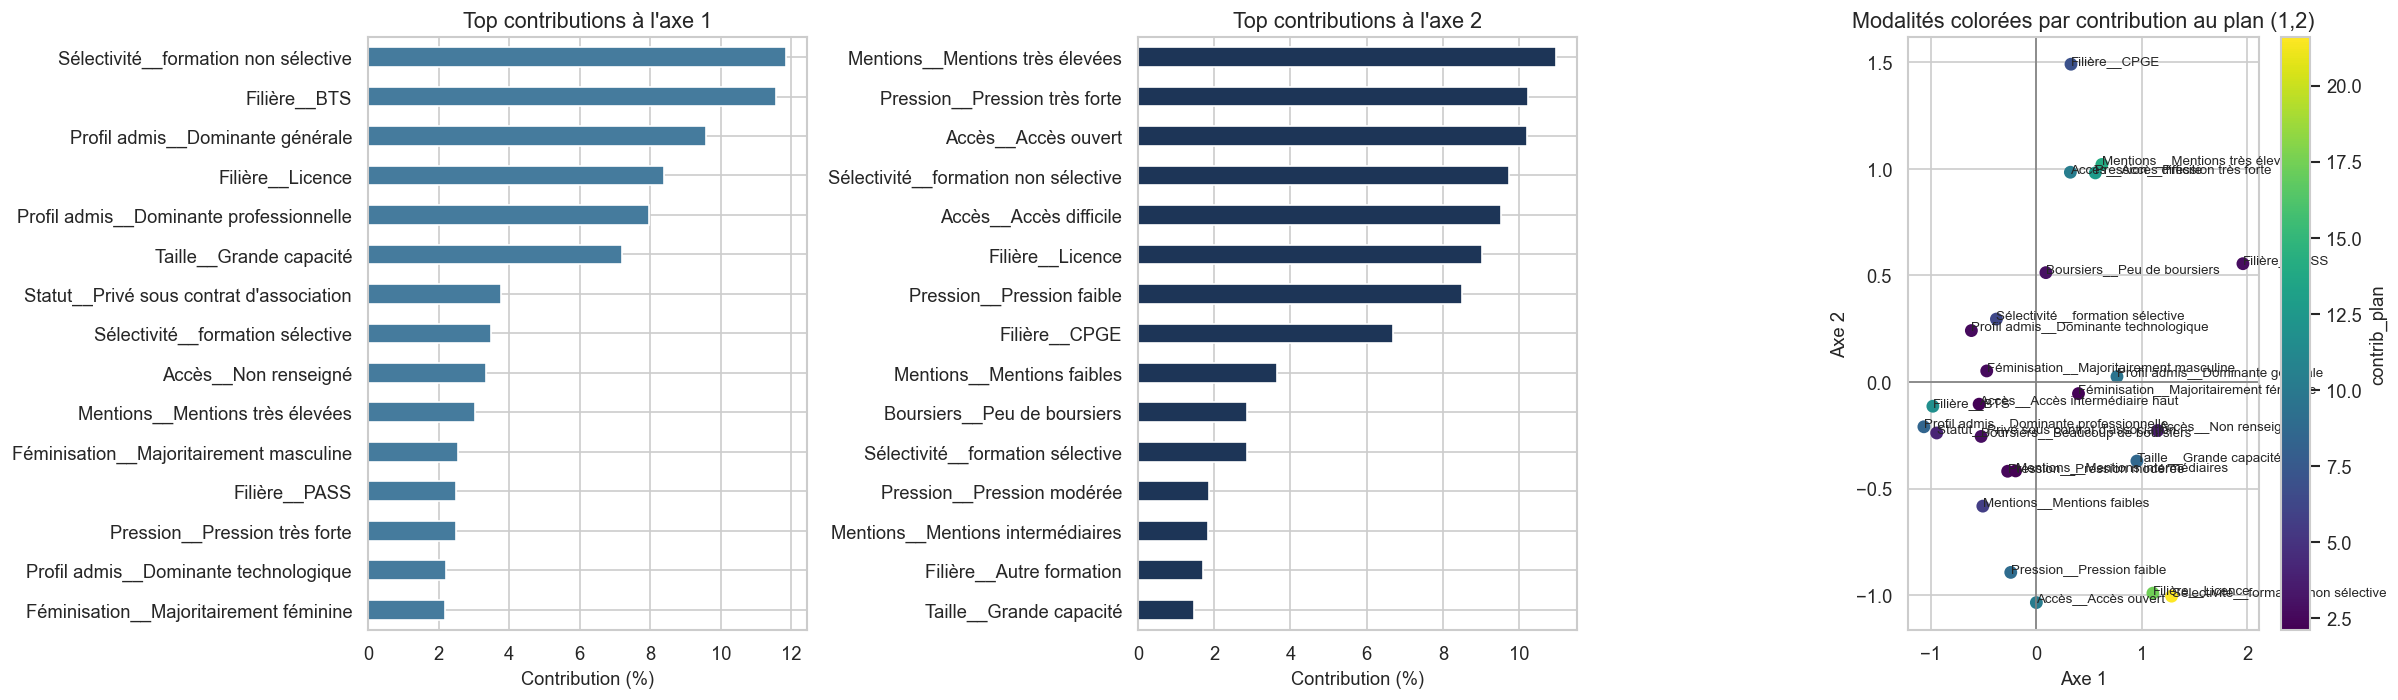

In [22]:
print("Top 20 des modalités contributives à l'axe 1 :")
display(mod_contrib[0].sort_values(ascending=False).head(20).to_frame("contribution_axe1"))

print("Top 20 des modalités contributives à l'axe 2 :")
display(mod_contrib[1].sort_values(ascending=False).head(20).to_frame("contribution_axe2"))

mod_contrib_plane = mod_contrib[0] + mod_contrib[1]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
mod_contrib[0].sort_values(ascending=False).head(15).sort_values().plot(kind="barh", ax=axes[0], color="#457b9d")
axes[0].set_title("Top contributions à l'axe 1")
axes[0].set_xlabel("Contribution (%)")

mod_contrib[1].sort_values(ascending=False).head(15).sort_values().plot(kind="barh", ax=axes[1], color="#1d3557")
axes[1].set_title("Top contributions à l'axe 2")
axes[1].set_xlabel("Contribution (%)")

plot_mca_modalities(mod_coords, "Modalités colorées par contribution au plan (1,2)", color=mod_contrib_plane.rename("contrib_plan"), ax=axes[2], top_n=25)

plt.tight_layout()
plt.show()

### Interprétation synthétique de l'ACM

La structure principale qui ressort est la suivante :

- **Axe 1** oppose surtout des formations de type **BTS**, plus souvent associées à une **dominante professionnelle** ou technologique, à des formations comme les **Licences**, **PASS** ou **Licence_LAS**, plus souvent associées à une **dominante générale**, à de **grandes capacités** et à une logique moins sélective.
- **Axe 2** ressemble davantage à un gradient de **tension académique** : d'un côté, des formations avec **pression forte**, **accès difficile** et **mentions très élevées** ; de l'autre, des formations plus **ouvertes**, avec une pression plus faible et un accès plus aisé.

Ce résultat est intéressant, car il montre que l'ACM ne fait pas apparaître seulement des types de filières : elle fait aussi émerger une seconde structuration liée à la **difficulté d'accès** et au **niveau scolaire des admis**.

### Représentation des individus

Dans le TP, la lecture des individus venait compléter celle des modalités. Avec plus de 13 000 formations, il faut rester lisible : on affiche donc un **échantillon visuel** d'individus, coloré par quelques variables parlantes.

Le but n'est pas d'interpréter chaque point, mais de vérifier si des **nuages distincts** apparaissent selon la sélectivité ou le type de filière.

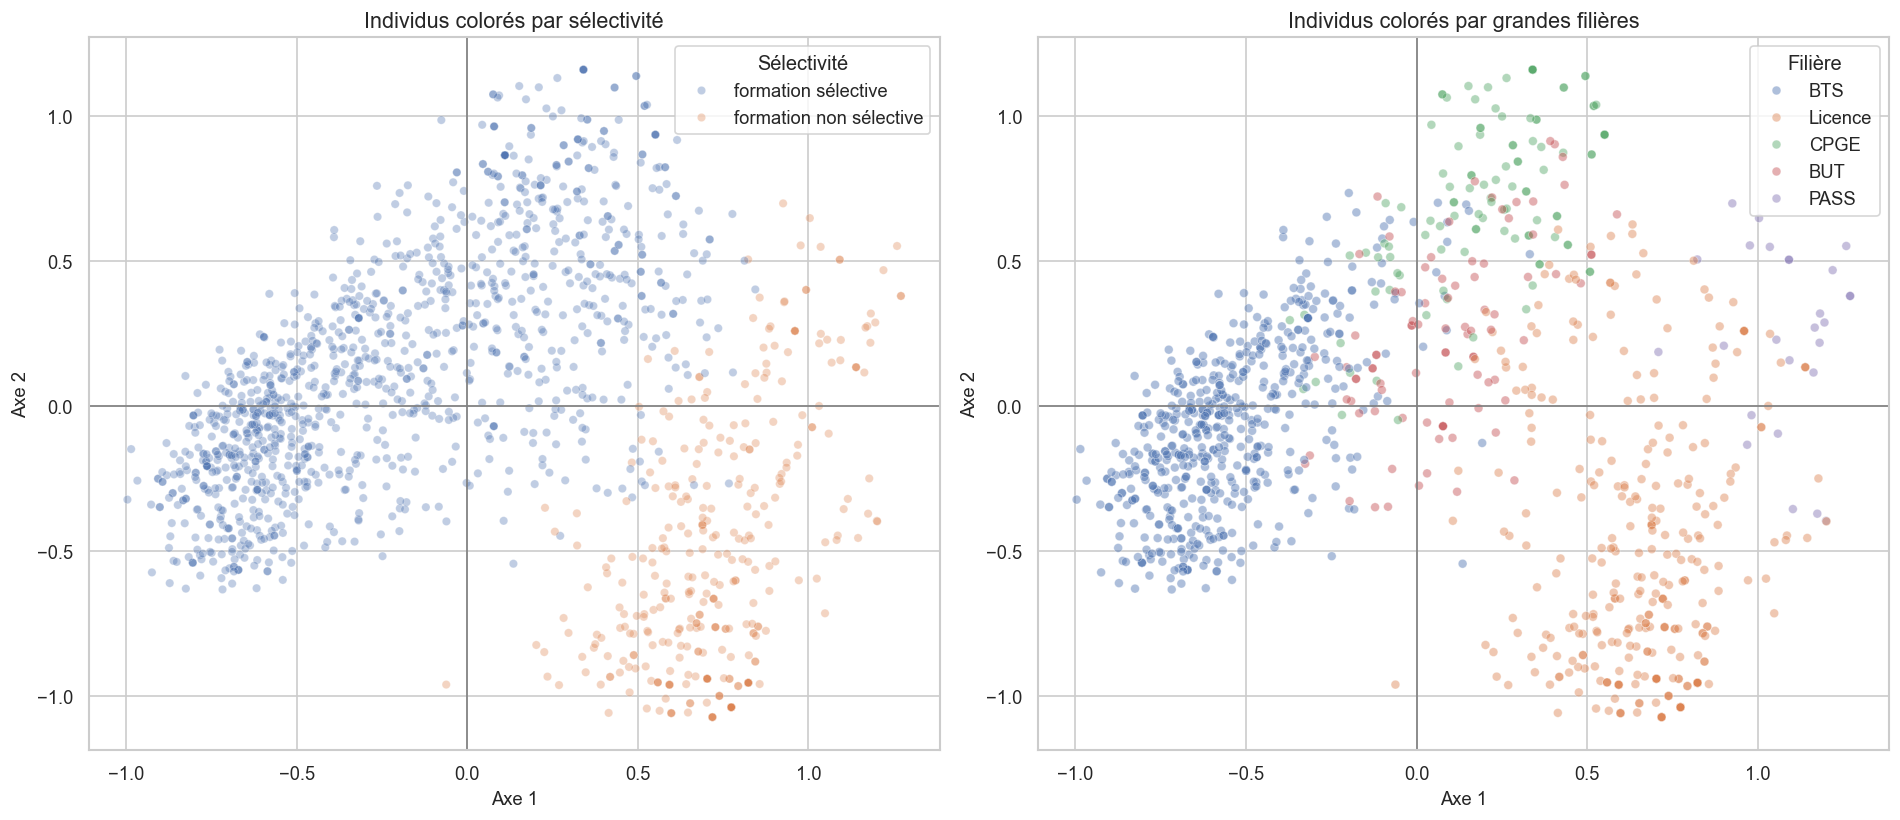

In [23]:
sample_idx = row_coords_mca.sample(n=min(1500, len(row_coords_mca)), random_state=42).index
plot_df = row_coords_mca.loc[sample_idx, [0, 1]].copy()
plot_df["Sélectivité"] = mca_df.loc[sample_idx, "Sélectivité"].values
plot_df["Filière"] = mca_df.loc[sample_idx, "Filière"].values

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.scatterplot(data=plot_df, x=0, y=1, hue="Sélectivité", alpha=0.35, s=25, ax=axes[0])
axes[0].axhline(0, color="grey", lw=1)
axes[0].axvline(0, color="grey", lw=1)
axes[0].set_title("Individus colorés par sélectivité")
axes[0].set_xlabel("Axe 1")
axes[0].set_ylabel("Axe 2")

filiere_focus = ["BTS", "Licence", "PASS", "CPGE", "BUT"]
focus_df = plot_df[plot_df["Filière"].isin(filiere_focus)].copy()
sns.scatterplot(data=focus_df, x=0, y=1, hue="Filière", alpha=0.45, s=28, ax=axes[1])
axes[1].axhline(0, color="grey", lw=1)
axes[1].axvline(0, color="grey", lw=1)
axes[1].set_title("Individus colorés par grandes filières")
axes[1].set_xlabel("Axe 1")
axes[1].set_ylabel("Axe 2")

plt.tight_layout()
plt.show()

### Lecture des individus

La superposition est encore importante, ce qui est normal avec autant d'observations. Malgré cela, on voit bien que :
- la **sélectivité** n'est pas répartie au hasard dans l'espace factoriel ;
- certaines grandes **filières** occupent des zones plus typiques que d'autres ;
- le plan principal fait donc émerger des **profils de formations** plutôt que des cas isolés.

On reste toutefois prudent : cette carte sert surtout d'appui visuel, pas d'outil de classification en soi.

### Éléments supplémentaires

Le TP d'origine se terminait par une lecture de variables supplémentaires. En Python, `prince` ne gère pas exactement cette étape comme `FactoMineR`, mais on peut en proposer un **équivalent pédagogique** :

- calculer les **barycentres régionaux** des formations dans l'espace factoriel ;
- corréler les axes à quelques **indicateurs quantitatifs de contexte**.

Cela permet de rester fidèle à l'esprit du TP : enrichir l'interprétation sans modifier la construction des axes.

,0,1
Région,,
Hauts-de-France,-0.083,-0.101
Autres régions,-0.045,-0.043
Nouvelle Aquitaine,-0.031,-0.018
Grand-Est,-0.020,-0.059
Occitanie,-0.014,0.004
Auvergne-Rhône-Alpes,0.043,0.013
Ile-de-France,0.124,0.152


,Axe 1,Axe 2
pression_num,0.251,0.415
acces_num,-0.158,-0.712
score_mentions,0.401,0.617
pct_boursiers,-0.239,-0.254
pct_filles,0.398,-0.019


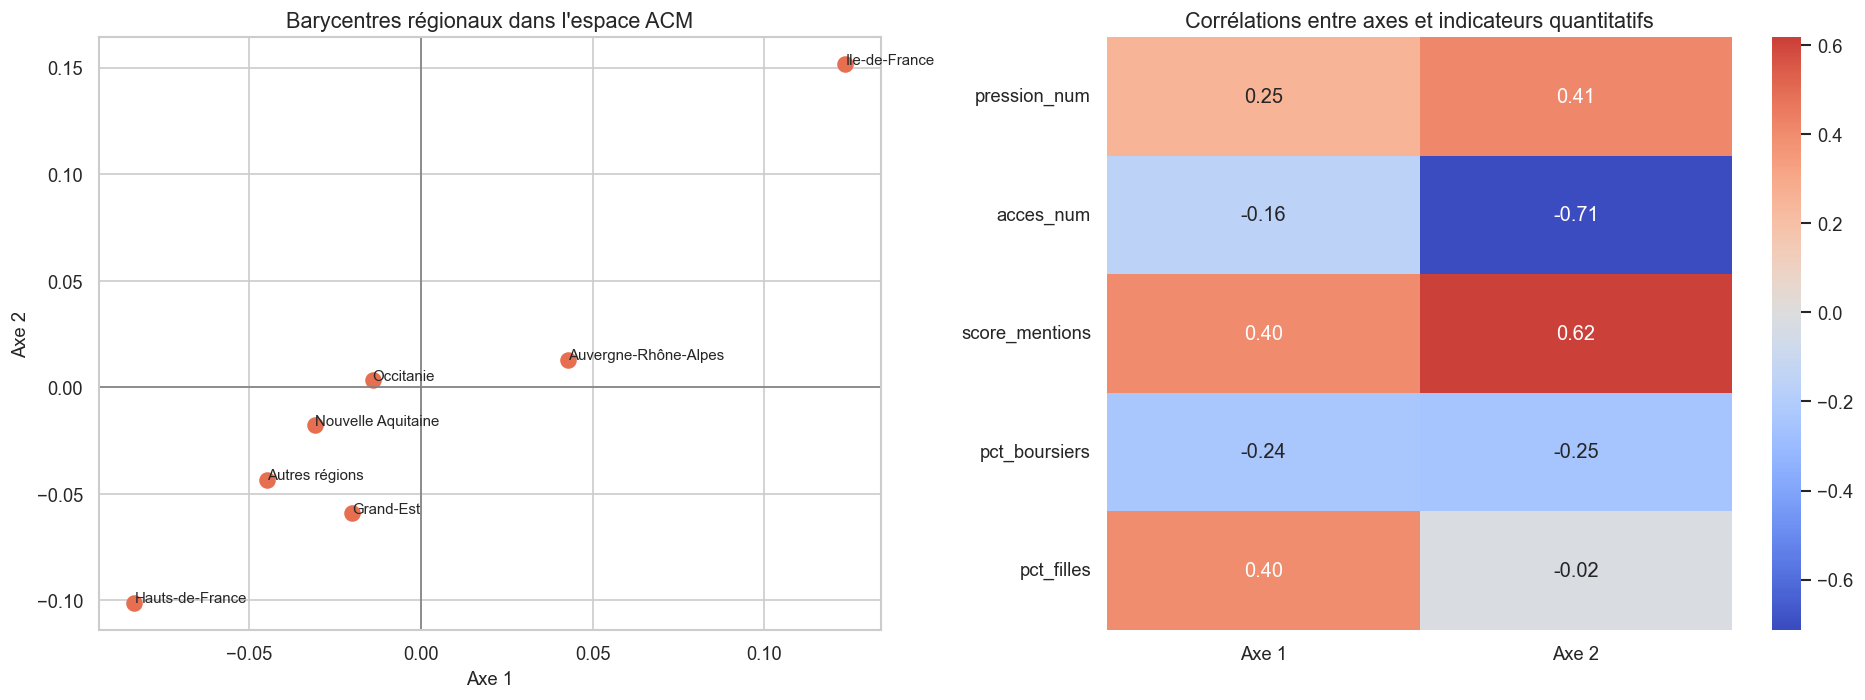

In [24]:
region_bary = row_coords_mca[[0, 1]].join(mca_df["Région"]).groupby("Région").mean().sort_values(0)
quanti_sup = pd.DataFrame({
    "pression_num": mca_base["pression"],
    "acces_num": mca_base["taux_acces"],
    "score_mentions": mca_base["score_mentions"],
    "pct_boursiers": mca_base["pct_boursiers"],
    "pct_filles": mca_base["pct_filles"],
})
correlations = pd.DataFrame({
    f"Axe {dim+1}": quanti_sup.apply(lambda s: s.corr(row_coords_mca[dim]))
    for dim in range(2)
})

display(region_bary.round(3))
display(correlations.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].axhline(0, color="grey", lw=1)
axes[0].axvline(0, color="grey", lw=1)
axes[0].scatter(region_bary[0], region_bary[1], s=80, color="#e76f51")
for idx, (x, y) in region_bary[[0, 1]].iterrows():
    axes[0].text(x, y, idx, fontsize=9)
axes[0].set_title("Barycentres régionaux dans l'espace ACM")
axes[0].set_xlabel("Axe 1")
axes[0].set_ylabel("Axe 2")

sns.heatmap(correlations, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Corrélations entre axes et indicateurs quantitatifs")

plt.tight_layout()
plt.show()

## Conclusion

En reprenant la progression du TP `CA_MCA_R.ipynb` en Python, on obtient deux lectures complémentaires des données Parcoursup.

### Ce que montre la CA

La CA met en évidence une **structure territoriale** des grandes filières : certaines catégories de formations sont davantage associées à certains ensembles régionaux que ce que l'indépendance laisserait attendre. L'axe 1 concentre l'essentiel de cette opposition, tandis que l'axe 2 apporte des nuances plus spécifiques.

### Ce que montre l'ACM

L'ACM révèle une structuration plus riche des formations :
- une première opposition entre grands **profils de filières** et **profils d'admis** ;
- une seconde opposition liée à la **pression**, au **niveau d'accès** et au **niveau scolaire** des admis.

### Ce qu'on peut conclure raisonnablement

Ces analyses suggèrent que l'espace Parcoursup n'est pas homogène : on voit apparaître des profils de formations différenciés à la fois par leur **nature**, leur **sélectivité**, leur **niveau académique** et leur **inscription territoriale**.

### Limites

Comme toujours avec la CA et l'ACM :
- les résultats décrivent des **associations de profils**, pas des relations causales ;
- le plan `(1,2)` est utile mais ne résume pas tout ;
- les modalités peu fréquentes ou faiblement représentées doivent être commentées avec prudence.

Le notebook reste donc fidèle à l'esprit du TP : une lecture **exploratoire, factorielle et pédagogique** des structures qualitatives du jeu de données.